In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import MultipleLocator
from math import sqrt
from numpy import concatenate
from pandas import read_csv, DataFrame, concat
from datetime import datetime
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import MinMaxScaler, StandardScaler

import keras.backend as K
from keras.layers import Multiply
from keras.models import Sequential ,Model
from keras.layers import Dense , Input , Reshape , Flatten ,Permute , Lambda , RepeatVector ,Conv1D , MaxPooling1D , Dropout, Bidirectional, Activation
from keras.layers import GRU, LSTM
from keras.utils.vis_utils import plot_model
from keras.optimizers import SGD,Adam
from keras.utils import np_utils   #np_utils
from keras.callbacks import TensorBoard  #TensorBoard可视化

In [2]:
# T:0
# H:1
# Surge:2
# Heave:4
# Force1:8
# 四级海况（波高2周期11.2水深50)
data_1 = pd.read_csv('t_2_11.2_50.csv')
data_1.head()

,T,H,Surge,Sway,Heave,Roll,Pitch,Yaw,Force1,Force2
0,0.1,-422.0,-0.0175,0.000289,-72.6,-1.160000e-09,-8.240000e-08,-1.350000e-09,4910.0,4910.0
1,0.2,-402.0,-0.2550,0.000348,-277.0,-1.430000e-07,2.830000e-03,-1.320000e-07,4690.0,4650.0
2,0.3,-380.0,1.2500,-0.035900,-413.0,-2.880000e-06,1.940000e-02,2.190000e-07,4650.0,4380.0
3,0.4,-356.0,4.1700,-0.070800,-339.0,-1.250000e-06,2.620000e-02,1.160000e-06,4790.0,4420.0
4,0.5,-330.0,3.0200,-0.097500,-242.0,4.580000e-07,2.310000e-02,2.060000e-06,4880.0,4550.0


In [3]:
data_1.describe()

,T,H,Surge,Sway,Heave,Roll,Pitch,Yaw,Force1,Force2
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.00000,40000.000000
mean,2000.050030,0.163048,5.607178,0.042822,-24.376800,-0.000003,-0.000050,0.000002,4994.70075,4957.142000
std,1154.714989,401.008617,93.005630,2.851035,379.528224,0.000376,0.018356,0.000222,753.57593,277.992156
min,0.100000,-1510.000000,-373.000000,-11.100000,-1390.000000,-0.001810,-0.067500,-0.001290,2290.00000,4120.000000
25%,1000.075015,-278.000000,-56.400000,-1.830000,-285.000000,-0.000251,-0.012900,-0.000136,4480.00000,4750.000000
50%,2000.050030,-5.955000,4.280000,0.030350,-31.600000,-0.000003,0.000474,-0.000001,4980.00000,4950.000000
75%,3000.025045,277.000000,64.700000,1.900000,236.000000,0.000246,0.012600,0.000135,5500.00000,5170.000000
max,4000.000060,1340.000000,452.000000,11.600000,1190.000000,0.001830,0.068400,0.001310,8110.00000,5700.000000


In [4]:
data_distance = np.hstack((np.array(data_1)[:, 1:8], np.array(data_1)[:, 8:10]))
print(data_distance)
print(data_distance.shape)

[[-4.22e+02 -1.75e-02  2.89e-04 ... -1.35e-09  4.91e+03  4.91e+03]
 [-4.02e+02 -2.55e-01  3.48e-04 ... -1.32e-07  4.69e+03  4.65e+03]
 [-3.80e+02  1.25e+00 -3.59e-02 ...  2.19e-07  4.65e+03  4.38e+03]
 ...
 [-2.13e+02 -1.20e+02 -5.24e-01 ...  2.37e-04  4.16e+03  5.16e+03]
 [-2.31e+02 -1.22e+02 -2.43e-01 ...  2.07e-04  4.14e+03  5.17e+03]
 [-2.49e+02 -1.22e+02 -6.28e-01 ...  8.97e-05  4.12e+03  5.17e+03]]
(40000, 9)


In [5]:
H_scaler = MinMaxScaler(feature_range=(-1, 1))
H = H_scaler.fit_transform(data_distance[:,0:1])
Surge_scaler = MinMaxScaler(feature_range=(-1, 1))
Surge = Surge_scaler.fit_transform(data_distance[:,1:2])
Sway_scaler = MinMaxScaler(feature_range=(-1, 1))
Sway = Sway_scaler.fit_transform(data_distance[:,2:3])
Heave_scaler = MinMaxScaler(feature_range=(-1, 1))
Heave = Heave_scaler.fit_transform(data_distance[:,3:4])
Roll_scaler = MinMaxScaler(feature_range=(-1, 1))
Roll = Roll_scaler.fit_transform(data_distance[:,4:5]*1e6)
Pitch_scaler = MinMaxScaler(feature_range=(-1, 1))
Pitch = Pitch_scaler.fit_transform(data_distance[:,5:6])
Yaw_scaler = MinMaxScaler(feature_range=(-1, 1))
Yaw = Yaw_scaler.fit_transform(data_distance[:,6:7]*1e6)
Force1_scaler = MinMaxScaler(feature_range=(-1, 1))
Force1 = Force1_scaler.fit_transform(data_distance[:,7:8])
Force2_scaler = MinMaxScaler(feature_range=(-1, 1))
Force2 = Force2_scaler.fit_transform(data_distance[:,8:9])
# zong_data = np.hstack(())

In [6]:
def series_to_supervised(data, n_in, n_out, dropnan=True):
#      '''
#      说明：将每一个特征（输入+输出）的单步-目标步长数全数列举出来
#      '''
    n_vars = 1 if type(data) is list else data.shape[1]
    df = DataFrame(data)
    cols, names = list(), list()
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
    agg = concat(cols, axis=1)
    agg.columns = names
    if dropnan:
        agg.dropna(inplace=True)
    return agg
def deal_data1(data, features_number, time_steps):
    '''
    适用：单/多特征，单/多预测步长
    data：数据集（仅包括输入+输出，且输出仅有一列并在最后）
    feature_number：输入+输出变量数
    n_in：预测步长
    结果解释：输入+输出+所需预测步长的输出（当为单特征时，输入、输出为同一列）
    '''
    process_data = series_to_supervised(data, time_steps, 1, dropnan=True)
    a = []
    for i in range(features_number, features_number*(time_steps+1)-1):
        a.append(i)
        i = i+1
    process_data.drop(process_data.columns[a], axis=1, inplace=True)
    return process_data.values
def deal_data2(data, features_number, time_steps):
    '''
    适用：多特征，单/多预测步长，不适用于单特征
    data：数据集（仅包括输入+输出，且输出仅有一列并在最后）
    feature_number：输入+输出变量数
    n_in：预测步长
    结果解释：输入+所需预测步长的输出
    '''
    process_data = series_to_supervised(data, time_steps, 1, dropnan=True)
    a = []
    for i in range(features_number-1, features_number*(time_steps+1)-1):
        a.append(i)
        i = i+1
    process_data.drop(process_data.columns[a], axis=1, inplace=True)
    return process_data.values
def split_sequence(dataset, n_past):
    x, y = list(), list()
    for i in range(len(dataset)):
        end_ix = i + n_past
        if end_ix > len(dataset):
            break
        seq_x, seq_y = dataset[i:end_ix, :-1], dataset[i, -1]
        x.append(seq_x)
        y.append(seq_y)
    return np.array(x), np.array(y)

def loss_plot(history, epo, length, width):
    # plot history
    plt.figure(figsize = (length, width))
    # 将x周的刻度线方向设置向内
    plt.rcParams['xtick.direction'] = 'in'  
    # 将y轴的刻度方向设置向内
    plt.rcParams['ytick.direction'] = 'in'  
    #设置字体以便支持中文
    plt.rcParams['font.sans-serif']=['SimHei']
    #为正常显示负号
    plt.rcParams['axes.unicode_minus'] = False 
    plt.plot(history.history['loss'], label = 'train loss')
    plt.plot(history.history['val_loss'], label = 'valid loss')
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()
    print(np.hstack((np.array(history.history['loss']).reshape(epo,1), np.array(history.history['val_loss']).reshape(epo,1))))

from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
def RNSE(valid_y,pre_Y):
    XP1 = valid_y.copy()
    XA1 = pre_Y.copy()
    print('RMSE(sklearn):',np.sqrt(mean_squared_error(XP1, XA1)))

def Acc(valid_y,pre_Y):
    XP1 = valid_y.copy()
    XA1 = pre_Y.copy()
    real1 = np.trapz(abs((XP1 - (XP1.sum()/(XP1.shape[0])))).reshape(XP1.shape[0],), dx=0.1)
    pre1 = np.trapz(abs((XA1 - (XA1.sum()/(XA1.shape[0])))).reshape(XA1.shape[0],), dx=0.1)
    Acc1 = 1 - abs(1 - (pre1/real1))
    print('Acc:', Acc1)

def FanGuiHua_surge(valid_sur_y,sur_pre_Y):
    fan_surge_real=Surge_scaler.inverse_transform(valid_sur_y)
    fan_surge_pre=Surge_scaler.inverse_transform(sur_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_surge_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_surge_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_surge_real,fan_surge_pre)
    return fan_surge_real,fan_surge_pre
def FanGuiHua_pitch(valid_pit_y,pit_pre_Y):
    fan_pitch_real=Pitch_scaler.inverse_transform(valid_pit_y)
    fan_pitch_pre=Pitch_scaler.inverse_transform(pit_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_pitch_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_pitch_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_pitch_real,fan_pitch_pre)
    return fan_pitch_real,fan_pitch_pre
def FanGuiHua_sway(valid_sway_y,sway_pre_Y):
    fan_sway_real=Sway_scaler.inverse_transform(valid_sway_y)
    fan_sway_pre=Sway_scaler.inverse_transform(sway_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_sway_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_sway_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_sway_real,fan_sway_pre)
    return fan_sway_real,fan_sway_pre
def FanGuiHua_roll(valid_roll_y,roll_pre_Y):
    fan_roll_real=Roll_scaler.inverse_transform(valid_roll_y)
    fan_roll_pre=Roll_scaler.inverse_transform(roll_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_roll_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_roll_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_roll_real,fan_roll_pre)
    return fan_roll_real,fan_roll_pre
def FanGuiHua_yaw(valid_yaw_y,yaw_pre_Y):
    fan_yaw_real=Yaw_scaler.inverse_transform(valid_yaw_y)
    fan_yaw_pre=Yaw_scaler.inverse_transform(yaw_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_yaw_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_yaw_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_yaw_real,fan_yaw_pre)
    return fan_yaw_real,fan_yaw_pre
def FanGuiHua_heave(valid_hea_y,hea_pre_Y):
    fan_heave_real=Heave_scaler.inverse_transform(valid_hea_y)
    fan_heave_pre=Heave_scaler.inverse_transform(hea_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_heave_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_heave_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_heave_real,fan_heave_pre)
    return fan_heave_real,fan_heave_pre
def FanGuiHua_force1(valid_for1_y,for1_pre_Y):
    fan_force1_real=Force1_scaler.inverse_transform(valid_for1_y)
    fan_force1_pre=Force1_scaler.inverse_transform(for1_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_force1_real,color='blue',label='real')   #真实曲线
    plt.plot(fan_force1_pre,color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_force1_real,fan_force1_pre)
    return fan_force1_real,fan_force1_pre
def FanGuiHua_force2(valid_for2_y,for2_pre_Y):
    fan_force2_real=Force2_scaler.inverse_transform(valid_for2_y)
    fan_force2_pre=Force2_scaler.inverse_transform(for2_pre_Y)
    plt.figure(figsize=(15,4), dpi=100)
    plt.plot(fan_force2_real,color='blue',label='real')   #真实曲线
    plt.plot(fan_force2_pre,color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
#     evaluate(fan_force2_real,fan_force2_pre)
    return fan_force2_real,fan_force2_pre

# 训练量=n_train_times_end-n_train_times_start
def split_train_valid(data_X, data_Y, n_train_times_start, n_train_times_end, n_valid_times):
    '''
    说明：将数据集划分为训练集和验证集
    疑问：先数据切割重组再划分数据集，先划分数据集再数据切割重组，有何区别影响？
    '''
    train_x, valid_x = data_X[n_train_times_start:n_train_times_end, :], data_X[n_train_times_end:n_valid_times, :]
    train_y, valid_y = data_Y[n_train_times_start:n_train_times_end], data_Y[n_train_times_end:n_valid_times]
    train_y = train_y.reshape((n_train_times_end-n_train_times_start, 1))
    valid_y = valid_y.reshape((n_valid_times-n_train_times_end, 1))
    return train_x, train_y, valid_x, valid_y

In [7]:
def Model_NN1(train_X, train_Y, valid_X, valid_Y, feature_number, lr=0.01, epochs=20, batch_size=256):
    input_layer = Input(shape=(feature_number,)) 
    D_layer1 = Dense(units = 150, activation = 'tanh')(input_layer)
    D_layer2 = Dense(units = 150, activation = 'tanh')(D_layer1)
    D_layer3 = Dense(units = 150, activation = 'tanh')(D_layer2)
    output_layer = Dense(1, activation = 'linear')(D_layer2)
    model = Model(inputs = input_layer, outputs = output_layer)
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_train_Y = model.predict(train_X)
    pre_Y = model.predict(valid_X)
    return model, history, pre_train_Y, pre_Y

In [8]:
def Model_NN(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential() #初始化模型
    model.add(Dense(150,input_shape=(train_X.shape[1], ),activation='tanh')) #添加一个隐含层，注：只是第一个隐含层需指定input_dim
    model.add(Dense(150,activation='tanh'))
    model.add(Dense(150,activation='tanh'))
    model.add(Dense(1,activation='linear')) #添加输出层
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_train_Y = model.predict(train_X)
    pre_Y = model.predict(valid_X)
    return model, history, pre_train_Y, pre_Y

In [9]:
# 归一化后的两个数据集
# 波浪-运动响应
# Force
# 输入500步长输出10步长
force150_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3500:,:], 4, 509)
force150_x1,force150_y1 = split_sequence(force150_scaled1, 500)
# print(force150_x1.shape)
# # 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)



# 输入500步长输出30步长
force150_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3480:,:], 4, 529)
force150_x3,force150_y3 = split_sequence(force150_scaled3, 500)
# print(force150_x3.shape)
# # 输入100步长输出3步长
# force1100_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[298:,:], 4, 102)
# force1100_x3,force1100_y3 = split_sequence(force1100_scaled3, 100)
# print(force1100_x3.shape)



# # 输入50步长输出5步长
# force150_scaled5 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[346:,:], 4, 54)
# force150_x5,force150_y5 = split_sequence(force150_scaled5, 50)
# print(force150_x5.shape)
# # 输入100步长输出5步长
# force1100_scaled5 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[296:,:], 4, 104)
# force1100_x5,force1100_y5 = split_sequence(force1100_scaled5, 100)
# print(force1100_x5.shape)



# # 输入50步长输出7步长
# force150_scaled7 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[344:,:], 4, 56)
# force150_x7,force150_y7 = split_sequence(force150_scaled7, 50)
# print(force150_x7.shape)
# # 输入100步长输出7步长
# force1100_scaled7 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[294:,:], 4, 106)
# force1100_x7,force1100_y7 = split_sequence(force1100_scaled7, 100)
# print(force1100_x7.shape)



# # 输入50步长输出9步长
# force150_scaled9 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[342:,:], 4, 58)
# force150_x9,force150_y9 = split_sequence(force150_scaled9, 50)
# print(force150_x9.shape)
# # 输入100步长输出9步长
# force1100_scaled9 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[292:,:], 4, 108)
# force1100_x9,force1100_y9 = split_sequence(force1100_scaled9, 100)
# print(force1100_x9.shape)



# 输入500步长输出20步长
force150_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3490:,:], 4, 519)
force150_x2,force150_y2 = split_sequence(force150_scaled2, 500)
# print(force150_x2.shape)
# # 输入100步长输出2步长
# force1100_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[299:,:], 4, 101)
# force1100_x2,force1100_y2 = split_sequence(force1100_scaled2, 100)
# print(force1100_x2.shape)


# 输入500步长输出40步长
force150_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3470:,:], 4, 539)
force150_x4,force150_y4 = split_sequence(force150_scaled4, 500)
# print(force150_x4.shape)
# # 输入100步长输出4步长
# force1100_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[297:,:], 4, 103)
# force1100_x4,force1100_y4 = split_sequence(force1100_scaled4, 100)
# print(force1100_x4.shape)



# # 输入50步长输出6步长
# force150_scaled6 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[345:,:], 4, 55)
# force150_x6,force150_y6 = split_sequence(force150_scaled6, 50)
# print(force150_x6.shape)
# # 输入100步长输出6步长
# force1100_scaled6 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[295:,:], 4, 105)
# force1100_x6,force1100_y6 = split_sequence(force1100_scaled6, 100)
# print(force1100_x6.shape)



# # 输入50步长输出8步长
# force150_scaled8 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[343:,:], 4, 57)
# force150_x8,force150_y8 = split_sequence(force150_scaled8, 50)
# print(force150_x8.shape)
# # 输入100步长输出8步长
# force1100_scaled8 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[293:,:], 4, 107)
# force1100_x8,force1100_y8 = split_sequence(force1100_scaled8, 100)
# print(force1100_x8.shape)

In [10]:
print(force150_y1)
print(force150_y2)
print(force150_y3)
print(force150_y4)

[-0.37113402 -0.39862543 -0.42268041 ...  0.07560137  0.08591065
  0.09278351]
[-0.37113402 -0.39862543 -0.42268041 ...  0.07560137  0.08591065
  0.09278351]
[-0.37113402 -0.39862543 -0.42268041 ...  0.07560137  0.08591065
  0.09278351]
[-0.37113402 -0.39862543 -0.42268041 ...  0.07560137  0.08591065
  0.09278351]


In [11]:
# 归一化后的两个数据集
# 波浪-运动响应
# 归一化后的两个数据集
# 波浪-运动响应
# Heave
# 输入500步长输出10步长
heave50_scaled1 = deal_data2(np.hstack((H,Heave))[3500:,:], 2, 509)
heave50_x1,heave50_y1 = split_sequence(heave50_scaled1, 500)
# print(heave50_x1.shape)
# # 输入100步长输出1步长
# heave100_scaled1 = deal_data2(np.hstack((H,Heave))[300:,:], 2, 100)
# heave100_x1,heave100_y1 = split_sequence(heave100_scaled1, 100)
# print(heave100_x1.shape)



# 输入500步长输出30步长
heave50_scaled3 = deal_data2(np.hstack((H,Heave))[3480:,:], 2, 529)
heave50_x3,heave50_y3 = split_sequence(heave50_scaled3, 500)
# print(heave50_x3.shape)
# # 输入100步长输出3步长
# heave100_scaled3 = deal_data2(np.hstack((H,Heave))[298:,:], 2, 102)
# heave100_x3,heave100_y3 = split_sequence(heave100_scaled3, 100)
# print(heave100_x3.shape)



# # 输入50步长输出5步长
# heave50_scaled5 = deal_data2(np.hstack((H,Heave))[346:,:], 2, 54)
# heave50_x5,heave50_y5 = split_sequence(heave50_scaled5, 50)
# print(heave50_x5.shape)
# # 输入100步长输出5步长
# heave100_scaled5 = deal_data2(np.hstack((H,Heave))[296:,:], 2, 104)
# heave100_x5,heave100_y5 = split_sequence(heave100_scaled5, 100)
# print(heave100_x5.shape)



# # 输入50步长输出7步长
# heave50_scaled7 = deal_data2(np.hstack((H,Heave))[344:,:], 2, 56)
# heave50_x7,heave50_y7 = split_sequence(heave50_scaled7, 50)
# print(heave50_x7.shape)
# # 输入100步长输出7步长
# heave100_scaled7 = deal_data2(np.hstack((H,Heave))[294:,:], 2, 106)
# heave100_x7,heave100_y7 = split_sequence(heave100_scaled7, 100)
# print(heave100_x7.shape)



# # 输入50步长输出9步长
# heave50_scaled9 = deal_data2(np.hstack((H,Heave))[342:,:], 2, 58)
# heave50_x9,heave50_y9 = split_sequence(heave50_scaled9, 50)
# print(heave50_x9.shape)
# # 输入100步长输出9步长
# heave100_scaled9 = deal_data2(np.hstack((H,Heave))[292:,:], 2, 108)
# heave100_x9,heave100_y9 = split_sequence(heave100_scaled9, 100)
# print(heave100_x9.shape)



# 输入500步长输出20步长
heave50_scaled2 = deal_data2(np.hstack((H,Heave))[3490:,:], 2, 519)
heave50_x2,heave50_y2 = split_sequence(heave50_scaled2, 500)
# print(heave50_x2.shape)
# # 输入100步长输出2步长
# heave100_scaled2 = deal_data2(np.hstack((H,Heave))[299:,:], 2, 101)
# heave100_x2,heave100_y2 = split_sequence(heave100_scaled2, 100)
# print(heave100_x2.shape)


# 输入500步长输出40步长
heave50_scaled4 = deal_data2(np.hstack((H,Heave))[3470:,:], 2, 539)
heave50_x4,heave50_y4 = split_sequence(heave50_scaled4, 500)
# print(heave50_x4.shape)
# # 输入100步长输出4步长
# heave100_scaled4 = deal_data2(np.hstack((H,Heave))[297:,:], 2, 103)
# heave100_x4,heave100_y4 = split_sequence(heave100_scaled4, 100)
# print(heave100_x4.shape)



# # 输入50步长输出6步长
# heave50_scaled6 = deal_data2(np.hstack((H,Heave))[345:,:], 2, 55)
# heave50_x6,heave50_y6 = split_sequence(heave50_scaled6, 50)
# print(heave50_x6.shape)
# # 输入100步长输出6步长
# heave100_scaled6 = deal_data2(np.hstack((H,Heave))[295:,:], 2, 105)
# heave100_x6,heave100_y6 = split_sequence(heave100_scaled6, 100)
# print(heave100_x6.shape)



# # 输入50步长输出8步长
# heave50_scaled8 = deal_data2(np.hstack((H,Heave))[343:,:], 2, 57)
# heave50_x8,heave50_y8 = split_sequence(heave50_scaled8, 50)
# print(heave50_x8.shape)
# # 输入100步长输出8步长
# heave100_scaled8 = deal_data2(np.hstack((H,Heave))[293:,:], 2, 107)
# heave100_x8,heave100_y8 = split_sequence(heave100_scaled8, 100)
# print(heave100_x8.shape)


# Surge
# 输入500步长输出10步长
surge50_scaled1 = deal_data2(np.hstack((H,Surge))[3500:,:], 2, 509)
surge50_x1,surge50_y1 = split_sequence(surge50_scaled1, 500)
# print(surge50_x1.shape)
# # 输入100步长输出1步长
# surge100_scaled1 = deal_data2(np.hstack((H,Surge))[300:,:], 2, 100)
# surge100_x1,surge100_y1 = split_sequence(surge100_scaled1, 100)
# print(surge100_x1.shape)



# 输入500步长输出30步长
surge50_scaled3 = deal_data2(np.hstack((H,Surge))[3480:,:], 2, 529)
surge50_x3,surge50_y3 = split_sequence(surge50_scaled3, 500)
# print(surge50_x3.shape)
# # 输入100步长输出3步长
# surge100_scaled3 = deal_data2(np.hstack((H,Surge))[298:,:], 2, 102)
# surge100_x3,surge100_y3 = split_sequence(surge100_scaled3, 100)
# print(surge100_x3.shape)



# # 输入50步长输出5步长
# surge50_scaled5 = deal_data2(np.hstack((H,Surge))[346:,:], 2, 54)
# surge50_x5,surge50_y5 = split_sequence(surge50_scaled5, 50)
# print(surge50_x5.shape)
# # 输入100步长输出5步长
# surge100_scaled5 = deal_data2(np.hstack((H,Surge))[296:,:], 2, 104)
# surge100_x5,surge100_y5 = split_sequence(surge100_scaled5, 100)
# print(surge100_x5.shape)



# # 输入50步长输出7步长
# surge50_scaled7 = deal_data2(np.hstack((H,Surge))[344:,:], 2, 56)
# surge50_x7,surge50_y7 = split_sequence(surge50_scaled7, 50)
# print(surge50_x7.shape)
# # 输入100步长输出7步长
# surge100_scaled7 = deal_data2(np.hstack((H,Surge))[294:,:], 2, 106)
# surge100_x7,surge100_y7 = split_sequence(surge100_scaled7, 100)
# print(surge100_x7.shape)



# # 输入50步长输出9步长
# surge50_scaled9 = deal_data2(np.hstack((H,Surge))[342:,:], 2, 58)
# surge50_x9,surge50_y9 = split_sequence(surge50_scaled9, 50)
# print(surge50_x9.shape)
# # 输入100步长输出9步长
# surge100_scaled9 = deal_data2(np.hstack((H,Surge))[292:,:], 2, 108)
# surge100_x9,surge100_y9 = split_sequence(surge100_scaled9, 100)
# print(surge100_x9.shape)



# 输入500步长输出20步长
surge50_scaled2 = deal_data2(np.hstack((H,Surge))[3490:,:], 2, 519)
surge50_x2,surge50_y2 = split_sequence(surge50_scaled2, 500)
# print(surge50_x2.shape)
# 输入100步长输出2步长
# surge100_scaled2 = deal_data2(np.hstack((H,Surge))[299:,:], 2, 101)
# surge100_x2,surge100_y2 = split_sequence(surge100_scaled2, 100)
# print(surge100_x2.shape)


# 输入500步长输出40步长
surge50_scaled4 = deal_data2(np.hstack((H,Surge))[3470:,:], 2, 539)
surge50_x4,surge50_y4 = split_sequence(surge50_scaled4, 500)
# print(surge50_x4.shape)
# # 输入100步长输出4步长
# surge100_scaled4 = deal_data2(np.hstack((H,Surge))[297:,:], 2, 103)
# surge100_x4,surge100_y4 = split_sequence(surge100_scaled4, 100)
# print(surge100_x4.shape)



# # 输入50步长输出6步长
# surge50_scaled6 = deal_data2(np.hstack((H,Surge))[345:,:], 2, 55)
# surge50_x6,surge50_y6 = split_sequence(surge50_scaled6, 50)
# print(surge50_x6.shape)
# # 输入100步长输出6步长
# surge100_scaled6 = deal_data2(np.hstack((H,Surge))[295:,:], 2, 105)
# surge100_x6,surge100_y6 = split_sequence(surge100_scaled6, 100)
# print(surge100_x6.shape)



# # 输入50步长输出8步长
# surge50_scaled8 = deal_data2(np.hstack((H,Surge))[343:,:], 2, 57)
# surge50_x8,surge50_y8 = split_sequence(surge50_scaled8, 50)
# print(surge50_x8.shape)
# # 输入100步长输出8步长
# surge100_scaled8 = deal_data2(np.hstack((H,Surge))[293:,:], 2, 107)
# surge100_x8,surge100_y8 = split_sequence(surge100_scaled8, 100)
# print(surge100_x8.shape)


# Pitch
# 输入500步长输出10步长
pitch50_scaled1 = deal_data2(np.hstack((H,Pitch))[3500:,:], 2, 509)
pitch50_x1,pitch50_y1 = split_sequence(pitch50_scaled1, 500)
# print(pitch50_x1.shape)
# # 输入100步长输出1步长
# pitch100_scaled1 = deal_data2(np.hstack((H,Pitch))[300:,:], 2, 100)
# pitch100_x1,pitch100_y1 = split_sequence(pitch100_scaled1, 100)
# print(pitch100_x1.shape)



# 输入500步长输出30步长
pitch50_scaled3 = deal_data2(np.hstack((H,Pitch))[3480:,:], 2, 529)
pitch50_x3,pitch50_y3 = split_sequence(pitch50_scaled3, 500)
# print(pitch50_x3.shape)
# # 输入100步长输出3步长
# pitch100_scaled3 = deal_data2(np.hstack((H,Pitch))[298:,:], 2, 102)
# pitch100_x3,pitch100_y3 = split_sequence(pitch100_scaled3, 100)
# print(pitch100_x3.shape)



# # 输入50步长输出5步长
# pitch50_scaled5 = deal_data2(np.hstack((H,Pitch))[346:,:], 2, 54)
# pitch50_x5,pitch50_y5 = split_sequence(pitch50_scaled5, 50)
# print(pitch50_x5.shape)
# # 输入100步长输出5步长
# pitch100_scaled5 = deal_data2(np.hstack((H,Pitch))[296:,:], 2, 104)
# pitch100_x5,pitch100_y5 = split_sequence(pitch100_scaled5, 100)
# print(pitch100_x5.shape)



# # 输入50步长输出7步长
# pitch50_scaled7 = deal_data2(np.hstack((H,Pitch))[344:,:], 2, 56)
# pitch50_x7,pitch50_y7 = split_sequence(pitch50_scaled7, 50)
# print(pitch50_x7.shape)
# # 输入100步长输出7步长
# pitch100_scaled7 = deal_data2(np.hstack((H,Pitch))[294:,:], 2, 106)
# pitch100_x7,pitch100_y7 = split_sequence(pitch100_scaled7, 100)
# print(pitch100_x7.shape)



# # 输入50步长输出9步长
# pitch50_scaled9 = deal_data2(np.hstack((H,Pitch))[342:,:], 2, 58)
# pitch50_x9,pitch50_y9 = split_sequence(pitch50_scaled9, 50)
# print(pitch50_x9.shape)
# # 输入100步长输出9步长
# pitch100_scaled9 = deal_data2(np.hstack((H,Pitch))[292:,:], 2, 108)
# pitch100_x9,pitch100_y9 = split_sequence(pitch100_scaled9, 100)
# print(pitch100_x9.shape)



# 输入500步长输出20步长
pitch50_scaled2 = deal_data2(np.hstack((H,Pitch))[3490:,:], 2, 519)
pitch50_x2,pitch50_y2 = split_sequence(pitch50_scaled2, 500)
# print(pitch50_x2.shape)
# # 输入100步长输出2步长
# pitch100_scaled2 = deal_data2(np.hstack((H,Pitch))[299:,:], 2, 101)
# pitch100_x2,pitch100_y2 = split_sequence(pitch100_scaled2, 100)
# print(pitch100_x2.shape)


# 输入500步长输出40步长
pitch50_scaled4 = deal_data2(np.hstack((H,Pitch))[3470:,:], 2, 539)
pitch50_x4,pitch50_y4 = split_sequence(pitch50_scaled4, 500)
# print(pitch50_x4.shape)
# # 输入100步长输出4步长
# pitch100_scaled4 = deal_data2(np.hstack((H,Pitch))[297:,:], 2, 103)
# pitch100_x4,pitch100_y4 = split_sequence(pitch100_scaled4, 100)
# print(pitch100_x4.shape)



# # 输入50步长输出6步长
# pitch50_scaled6 = deal_data2(np.hstack((H,Pitch))[345:,:], 2, 55)
# pitch50_x6,pitch50_y6 = split_sequence(pitch50_scaled6, 50)
# print(pitch50_x6.shape)
# # 输入100步长输出6步长
# pitch100_scaled6 = deal_data2(np.hstack((H,Pitch))[295:,:], 2, 105)
# pitch100_x6,pitch100_y6 = split_sequence(pitch100_scaled6, 100)
# print(pitch100_x6.shape)



# # 输入50步长输出8步长
# pitch50_scaled8 = deal_data2(np.hstack((H,Pitch))[343:,:], 2, 57)
# pitch50_x8,pitch50_y8 = split_sequence(pitch50_scaled8, 50)
# print(pitch50_x8.shape)
# # 输入100步长输出8步长
# pitch100_scaled8 = deal_data2(np.hstack((H,Pitch))[293:,:], 2, 107)
# pitch100_x8,pitch100_y8 = split_sequence(pitch100_scaled8, 100)
# print(pitch100_x8.shape)

### 模型比较

In [12]:
# GRU
def Model_GRU(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(GRU(25, activation='tanh', return_sequences=True, input_shape=(train_X.shape[1], train_X.shape[2])))  #25×5的数据输入
#     model.add(Dropout(0.3))
#     model.add(GRU(100, activation='tanh', return_sequences=True))
#     model.add(Dropout(0.3))
#     model.add(GRU(100, activation='tanh'))
#     model.add(Dropout(0.3))
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

#### 系泊缆力联合预测（时间窗500输出；步长10）

In [13]:
# 未来运动预测模型建立
train_heave50_x1, train_heave50_y1, valid_heave50_x1, valid_heave50_y1 = split_train_valid(heave50_x1,heave50_y1, 4500, 7500, 12000)
heave50_model1, heave50_history1, pre_heave50_Y1 = Model_GRU(train_heave50_x1, train_heave50_y1, valid_heave50_x1, valid_heave50_y1, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x1, train_surge50_y1, valid_surge50_x1, valid_surge50_y1 = split_train_valid(surge50_x1,surge50_y1,4200, 7500, 12000)
surge50_model1, surge50_history1, pre_surge50_Y1 = Model_GRU(train_surge50_x1, train_surge50_y1, valid_surge50_x1, valid_surge50_y1, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x1, train_pitch50_y1, valid_pitch50_x1, valid_pitch50_y1 = split_train_valid(pitch50_x1,pitch50_y1, 4500, 7500, 12000)
pitch50_model1, pitch50_history1, pre_pitch50_Y1 = Model_GRU(train_pitch50_x1, train_pitch50_y1, valid_pitch50_x1, valid_pitch50_y1, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

E:\Anaconda\envs\TensorFlow_env\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


Epoch 1/30
60/60 - 13s - loss: 0.0891 - val_loss: 0.0846 - 13s/epoch - 218ms/step
Epoch 2/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 143ms/step
Epoch 3/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 143ms/step
Epoch 4/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 144ms/step
Epoch 5/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 155ms/step
Epoch 6/30
60/60 - 8s - loss: 0.0884 - val_loss: 0.0846 - 8s/epoch - 140ms/step
Epoch 7/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 142ms/step
Epoch 8/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 147ms/step
Epoch 9/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 143ms/step
Epoch 10/30
60/60 - 8s - loss: 0.0884 - val_loss: 0.0846 - 8s/epoch - 141ms/step
Epoch 11/30
60/60 - 8s - loss: 0.0884 - val_loss: 0.0846 - 8s/epoch - 141ms/step
Epoch 12/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 155ms/step
Epoch 13/30
60/60 - 9s - loss: 0.08

Epoch 21/30
60/60 - 9s - loss: 0.0723 - val_loss: 0.0701 - 9s/epoch - 147ms/step
Epoch 22/30
60/60 - 9s - loss: 0.0723 - val_loss: 0.0701 - 9s/epoch - 142ms/step
Epoch 23/30
60/60 - 8s - loss: 0.0723 - val_loss: 0.0701 - 8s/epoch - 140ms/step
Epoch 24/30
60/60 - 9s - loss: 0.0723 - val_loss: 0.0701 - 9s/epoch - 155ms/step
Epoch 25/30
60/60 - 8s - loss: 0.0723 - val_loss: 0.0701 - 8s/epoch - 139ms/step
Epoch 26/30
60/60 - 8s - loss: 0.0722 - val_loss: 0.0701 - 8s/epoch - 138ms/step
Epoch 27/30
60/60 - 8s - loss: 0.0722 - val_loss: 0.0701 - 8s/epoch - 138ms/step
Epoch 28/30
60/60 - 9s - loss: 0.0722 - val_loss: 0.0701 - 9s/epoch - 144ms/step
Epoch 29/30
60/60 - 9s - loss: 0.0722 - val_loss: 0.0701 - 9s/epoch - 144ms/step
Epoch 30/30
60/60 - 8s - loss: 0.0722 - val_loss: 0.0701 - 8s/epoch - 139ms/step
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_2 (GRU)                 (None, 

In [14]:
pretrain_heave50_Y1 = heave50_model1.predict(train_heave50_x1)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y1 = surge50_model1.predict(train_surge50_x1[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y1 = pitch50_model1.predict(train_pitch50_x1)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y1.shape)
print(pretrain_surge50_Y1.shape)
print(pretrain_pitch50_Y1.shape)

94/94 [==============================] - 4s 37ms/step
(3000, 500, 1)
(3000, 500, 1)
(3000, 500, 1)


In [15]:
# 输入500步长输出10步长Force1
force150_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3500:,:], 4, 509)
force150_x1,force150_y1 = split_sequence(force150_scaled1, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [16]:
train_force150_x1, train_force150_y1, valid_force150_x1, valid_force150_y1 = split_train_valid(force150_x1,force150_y1, 4500, 7500, 12000)
train50_x_Force1, valid50_x_Force1 = np.hstack((pretrain_heave50_Y1, pretrain_surge50_Y1, pretrain_pitch50_Y1)), np.hstack((pre_heave50_Y1, pre_surge50_Y1, pre_pitch50_Y1))
train50_y_Force1, valid50_y_Force1 = train_force150_y1, valid_force150_y1

In [17]:
N_model50_Force1, N_history50_Force1, N_pre50_train_Y_Force1, N_pre50_Y_Force1 = Model_NN(train50_x_Force1, train50_y_Force1, valid50_x_Force1, valid50_y_Force1, lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000
12/12 - 2s - loss: 0.2888 - val_loss: 0.0657 - 2s/epoch - 165ms/step
Epoch 2/1000
12/12 - 0s - loss: 0.0896 - val_loss: 0.0647 - 136ms/epoch - 11ms/step
Epoch 3/1000
12/12 - 0s - loss: 0.0671 - val_loss: 0.0597 - 146ms/epoch - 12ms/step
Epoch 4/1000
12/12 - 0s - loss: 0.0597 - val_loss: 0.0526 - 162ms/epoch - 13ms/step
Epoch 5/1000
12/12 - 0s - loss: 0.0507 - val_loss: 0.0439 - 126ms/epoch - 10ms/step
Epoch 6/1000
12/12 - 0s - loss: 0.0405 - val_loss: 0.0346 - 139ms/epoch - 12ms/step
Epoch 7/1000
12/12 - 0s - loss: 0.0327 - val_loss: 0.0290 - 141ms/epoch - 12ms/step
Epoch 8/1000
12/12 - 0s - loss: 0.0282 - val_loss: 0.0245 - 126ms/epoch - 10ms/step
Epoch 9/1000
12/12 - 0s - loss: 0.0251 - val_loss: 0.0248 - 138ms/epoch - 11ms/step
Epoch 10/1000
12/12 - 0s - loss: 0.0218 - val_loss: 0.0196 - 126ms/epoch - 10ms/step
Epoch 11/1000
12/12 - 0s - loss: 0.0197 - val_loss: 0.0185 - 138ms/epoch - 11ms/step
Epoch 12/1000
12/12 - 0s - loss: 0.0185 - val_loss: 0.0170 - 127ms/epoch - 1

Epoch 98/1000
12/12 - 0s - loss: 0.0104 - val_loss: 0.0121 - 115ms/epoch - 10ms/step
Epoch 99/1000
12/12 - 0s - loss: 0.0095 - val_loss: 0.0100 - 118ms/epoch - 10ms/step
Epoch 100/1000
12/12 - 0s - loss: 0.0096 - val_loss: 0.0093 - 116ms/epoch - 10ms/step
Epoch 101/1000
12/12 - 0s - loss: 0.0105 - val_loss: 0.0105 - 114ms/epoch - 9ms/step
Epoch 102/1000
12/12 - 0s - loss: 0.0111 - val_loss: 0.0095 - 115ms/epoch - 10ms/step
Epoch 103/1000
12/12 - 0s - loss: 0.0105 - val_loss: 0.0117 - 121ms/epoch - 10ms/step
Epoch 104/1000
12/12 - 0s - loss: 0.0095 - val_loss: 0.0102 - 114ms/epoch - 9ms/step
Epoch 105/1000
12/12 - 0s - loss: 0.0093 - val_loss: 0.0091 - 129ms/epoch - 11ms/step
Epoch 106/1000
12/12 - 0s - loss: 0.0103 - val_loss: 0.0102 - 133ms/epoch - 11ms/step
Epoch 107/1000
12/12 - 0s - loss: 0.0109 - val_loss: 0.0098 - 131ms/epoch - 11ms/step
Epoch 108/1000
12/12 - 0s - loss: 0.0106 - val_loss: 0.0111 - 135ms/epoch - 11ms/step
Epoch 109/1000
12/12 - 0s - loss: 0.0094 - val_loss: 0.010

Epoch 194/1000
12/12 - 0s - loss: 0.0088 - val_loss: 0.0083 - 117ms/epoch - 10ms/step
Epoch 195/1000
12/12 - 0s - loss: 0.0083 - val_loss: 0.0083 - 115ms/epoch - 10ms/step
Epoch 196/1000
12/12 - 0s - loss: 0.0082 - val_loss: 0.0079 - 115ms/epoch - 10ms/step
Epoch 197/1000
12/12 - 0s - loss: 0.0086 - val_loss: 0.0081 - 124ms/epoch - 10ms/step
Epoch 198/1000
12/12 - 0s - loss: 0.0086 - val_loss: 0.0086 - 113ms/epoch - 9ms/step
Epoch 199/1000
12/12 - 0s - loss: 0.0088 - val_loss: 0.0089 - 122ms/epoch - 10ms/step
Epoch 200/1000
12/12 - 0s - loss: 0.0090 - val_loss: 0.0082 - 131ms/epoch - 11ms/step
Epoch 201/1000
12/12 - 0s - loss: 0.0089 - val_loss: 0.0080 - 128ms/epoch - 11ms/step
Epoch 202/1000
12/12 - 0s - loss: 0.0085 - val_loss: 0.0082 - 129ms/epoch - 11ms/step
Epoch 203/1000
12/12 - 0s - loss: 0.0082 - val_loss: 0.0078 - 120ms/epoch - 10ms/step
Epoch 204/1000
12/12 - 0s - loss: 0.0084 - val_loss: 0.0080 - 117ms/epoch - 10ms/step
Epoch 205/1000
12/12 - 0s - loss: 0.0085 - val_loss: 0.

Epoch 290/1000
12/12 - 0s - loss: 0.0080 - val_loss: 0.0075 - 117ms/epoch - 10ms/step
Epoch 291/1000
12/12 - 0s - loss: 0.0082 - val_loss: 0.0072 - 113ms/epoch - 9ms/step
Epoch 292/1000
12/12 - 0s - loss: 0.0084 - val_loss: 0.0074 - 125ms/epoch - 10ms/step
Epoch 293/1000
12/12 - 0s - loss: 0.0083 - val_loss: 0.0080 - 114ms/epoch - 9ms/step
Epoch 294/1000
12/12 - 0s - loss: 0.0081 - val_loss: 0.0079 - 118ms/epoch - 10ms/step
Epoch 295/1000
12/12 - 0s - loss: 0.0077 - val_loss: 0.0074 - 115ms/epoch - 10ms/step
Epoch 296/1000
12/12 - 0s - loss: 0.0075 - val_loss: 0.0072 - 124ms/epoch - 10ms/step
Epoch 297/1000
12/12 - 0s - loss: 0.0075 - val_loss: 0.0073 - 121ms/epoch - 10ms/step
Epoch 298/1000
12/12 - 0s - loss: 0.0076 - val_loss: 0.0074 - 114ms/epoch - 9ms/step
Epoch 299/1000
12/12 - 0s - loss: 0.0076 - val_loss: 0.0074 - 113ms/epoch - 9ms/step
Epoch 300/1000
12/12 - 0s - loss: 0.0077 - val_loss: 0.0075 - 115ms/epoch - 10ms/step
Epoch 301/1000
12/12 - 0s - loss: 0.0078 - val_loss: 0.007

Epoch 386/1000
12/12 - 0s - loss: 0.0093 - val_loss: 0.0150 - 115ms/epoch - 10ms/step
Epoch 387/1000
12/12 - 0s - loss: 0.0145 - val_loss: 0.0205 - 136ms/epoch - 11ms/step
Epoch 388/1000
12/12 - 0s - loss: 0.0139 - val_loss: 0.0085 - 115ms/epoch - 10ms/step
Epoch 389/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.0164 - 119ms/epoch - 10ms/step
Epoch 390/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0111 - 120ms/epoch - 10ms/step
Epoch 391/1000
12/12 - 0s - loss: 0.0133 - val_loss: 0.0086 - 115ms/epoch - 10ms/step
Epoch 392/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0201 - 116ms/epoch - 10ms/step
Epoch 393/1000
12/12 - 0s - loss: 0.0121 - val_loss: 0.0095 - 116ms/epoch - 10ms/step
Epoch 394/1000
12/12 - 0s - loss: 0.0116 - val_loss: 0.0138 - 115ms/epoch - 10ms/step
Epoch 395/1000
12/12 - 0s - loss: 0.0108 - val_loss: 0.0113 - 114ms/epoch - 9ms/step
Epoch 396/1000
12/12 - 0s - loss: 0.0096 - val_loss: 0.0078 - 113ms/epoch - 9ms/step
Epoch 397/1000
12/12 - 0s - loss: 0.0102 - val_loss: 0.0

...

Epoch 578/1000
12/12 - 0s - loss: 0.0056 - val_loss: 0.0071 - 117ms/epoch - 10ms/step
Epoch 579/1000
12/12 - 0s - loss: 0.0061 - val_loss: 0.0082 - 113ms/epoch - 9ms/step
Epoch 580/1000
12/12 - 0s - loss: 0.0058 - val_loss: 0.0079 - 116ms/epoch - 10ms/step
Epoch 581/1000
12/12 - 0s - loss: 0.0064 - val_loss: 0.0094 - 115ms/epoch - 10ms/step
Epoch 582/1000
12/12 - 0s - loss: 0.0063 - val_loss: 0.0094 - 114ms/epoch - 9ms/step
Epoch 583/1000
12/12 - 0s - loss: 0.0072 - val_loss: 0.0112 - 114ms/epoch - 9ms/step
Epoch 584/1000
12/12 - 0s - loss: 0.0071 - val_loss: 0.0126 - 118ms/epoch - 10ms/step
Epoch 585/1000
12/12 - 0s - loss: 0.0087 - val_loss: 0.0119 - 122ms/epoch - 10ms/step
Epoch 586/1000
12/12 - 0s - loss: 0.0076 - val_loss: 0.0078 - 116ms/epoch - 10ms/step
Epoch 587/1000
12/12 - 0s - loss: 0.0063 - val_loss: 0.0082 - 114ms/epoch - 9ms/step
Epoch 588/1000
12/12 - 0s - loss: 0.0065 - val_loss: 0.0099 - 115ms/epoch - 10ms/step
Epoch 589/1000
12/12 - 0s - loss: 0.0074 - val_loss: 0.010

Epoch 674/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0087 - 117ms/epoch - 10ms/step
Epoch 675/1000
12/12 - 0s - loss: 0.0095 - val_loss: 0.0208 - 114ms/epoch - 9ms/step
Epoch 676/1000
12/12 - 0s - loss: 0.0131 - val_loss: 0.0123 - 112ms/epoch - 9ms/step
Epoch 677/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0147 - 126ms/epoch - 10ms/step
Epoch 678/1000
12/12 - 0s - loss: 0.0134 - val_loss: 0.0142 - 138ms/epoch - 11ms/step
Epoch 679/1000
12/12 - 0s - loss: 0.0119 - val_loss: 0.0160 - 115ms/epoch - 10ms/step
Epoch 680/1000
12/12 - 0s - loss: 0.0104 - val_loss: 0.0207 - 116ms/epoch - 10ms/step
Epoch 681/1000
12/12 - 0s - loss: 0.0130 - val_loss: 0.0084 - 126ms/epoch - 10ms/step
Epoch 682/1000
12/12 - 0s - loss: 0.0077 - val_loss: 0.0079 - 113ms/epoch - 9ms/step
Epoch 683/1000
12/12 - 0s - loss: 0.0057 - val_loss: 0.0078 - 114ms/epoch - 9ms/step
Epoch 684/1000
12/12 - 0s - loss: 0.0054 - val_loss: 0.0074 - 129ms/epoch - 11ms/step
Epoch 685/1000
12/12 - 0s - loss: 0.0050 - val_loss: 0.007

Epoch 770/1000
12/12 - 0s - loss: 0.0059 - val_loss: 0.0089 - 154ms/epoch - 13ms/step
Epoch 771/1000
12/12 - 0s - loss: 0.0052 - val_loss: 0.0082 - 118ms/epoch - 10ms/step
Epoch 772/1000
12/12 - 0s - loss: 0.0047 - val_loss: 0.0096 - 119ms/epoch - 10ms/step
Epoch 773/1000
12/12 - 0s - loss: 0.0051 - val_loss: 0.0081 - 115ms/epoch - 10ms/step
Epoch 774/1000
12/12 - 0s - loss: 0.0045 - val_loss: 0.0118 - 115ms/epoch - 10ms/step
Epoch 775/1000
12/12 - 0s - loss: 0.0059 - val_loss: 0.0086 - 115ms/epoch - 10ms/step
Epoch 776/1000
12/12 - 0s - loss: 0.0050 - val_loss: 0.0159 - 114ms/epoch - 9ms/step
Epoch 777/1000
12/12 - 0s - loss: 0.0090 - val_loss: 0.0103 - 114ms/epoch - 9ms/step
Epoch 778/1000
12/12 - 0s - loss: 0.0067 - val_loss: 0.0154 - 118ms/epoch - 10ms/step
Epoch 779/1000
12/12 - 0s - loss: 0.0109 - val_loss: 0.0106 - 125ms/epoch - 10ms/step
Epoch 780/1000
12/12 - 0s - loss: 0.0089 - val_loss: 0.0110 - 114ms/epoch - 9ms/step
Epoch 781/1000
12/12 - 0s - loss: 0.0080 - val_loss: 0.01

Epoch 866/1000
12/12 - 0s - loss: 0.0054 - val_loss: 0.0117 - 152ms/epoch - 13ms/step
Epoch 867/1000
12/12 - 0s - loss: 0.0058 - val_loss: 0.0122 - 127ms/epoch - 11ms/step
Epoch 868/1000
12/12 - 0s - loss: 0.0064 - val_loss: 0.0117 - 150ms/epoch - 12ms/step
Epoch 869/1000
12/12 - 0s - loss: 0.0058 - val_loss: 0.0128 - 133ms/epoch - 11ms/step
Epoch 870/1000
12/12 - 0s - loss: 0.0073 - val_loss: 0.0170 - 136ms/epoch - 11ms/step
Epoch 871/1000
12/12 - 0s - loss: 0.0090 - val_loss: 0.0181 - 137ms/epoch - 11ms/step
Epoch 872/1000
12/12 - 0s - loss: 0.0112 - val_loss: 0.0199 - 140ms/epoch - 12ms/step
Epoch 873/1000
12/12 - 0s - loss: 0.0123 - val_loss: 0.0250 - 112ms/epoch - 9ms/step
Epoch 874/1000
12/12 - 0s - loss: 0.0116 - val_loss: 0.0228 - 118ms/epoch - 10ms/step
Epoch 875/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0138 - 149ms/epoch - 12ms/step
Epoch 876/1000
12/12 - 0s - loss: 0.0119 - val_loss: 0.0116 - 129ms/epoch - 11ms/step
Epoch 877/1000
12/12 - 0s - loss: 0.0075 - val_loss: 0.

Epoch 962/1000
12/12 - 0s - loss: 0.0077 - val_loss: 0.0103 - 115ms/epoch - 10ms/step
Epoch 963/1000
12/12 - 0s - loss: 0.0043 - val_loss: 0.0099 - 114ms/epoch - 9ms/step
Epoch 964/1000
12/12 - 0s - loss: 0.0041 - val_loss: 0.0095 - 115ms/epoch - 10ms/step
Epoch 965/1000
12/12 - 0s - loss: 0.0041 - val_loss: 0.0113 - 116ms/epoch - 10ms/step
Epoch 966/1000
12/12 - 0s - loss: 0.0045 - val_loss: 0.0115 - 116ms/epoch - 10ms/step
Epoch 967/1000
12/12 - 0s - loss: 0.0043 - val_loss: 0.0115 - 134ms/epoch - 11ms/step
Epoch 968/1000
12/12 - 0s - loss: 0.0049 - val_loss: 0.0107 - 116ms/epoch - 10ms/step
Epoch 969/1000
12/12 - 0s - loss: 0.0053 - val_loss: 0.0112 - 114ms/epoch - 9ms/step
Epoch 970/1000
12/12 - 0s - loss: 0.0065 - val_loss: 0.0126 - 134ms/epoch - 11ms/step
Epoch 971/1000
12/12 - 0s - loss: 0.0065 - val_loss: 0.0112 - 127ms/epoch - 11ms/step
Epoch 972/1000
12/12 - 0s - loss: 0.0058 - val_loss: 0.0115 - 132ms/epoch - 11ms/step
Epoch 973/1000
12/12 - 0s - loss: 0.0055 - val_loss: 0.0

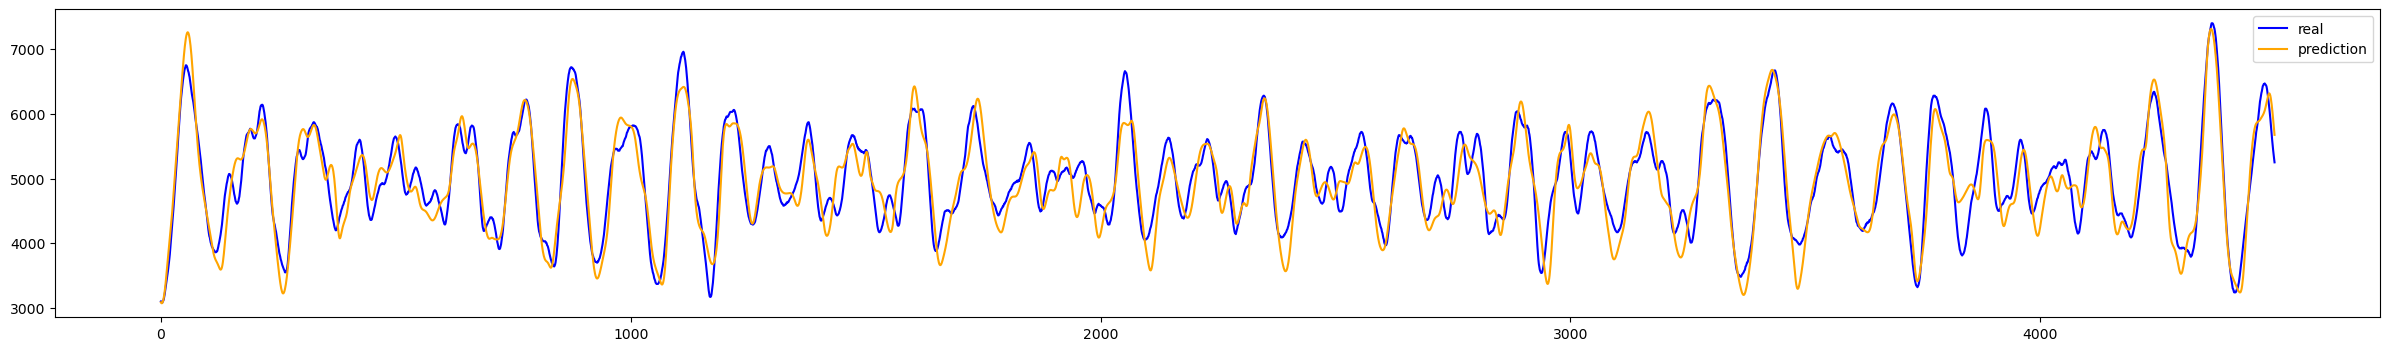

In [18]:
fan_force150_real1,fan_force150_pre1 = FanGuiHua_force1(valid50_y_Force1,N_pre50_Y_Force1)

np.savetxt('force1500_步长10_GRU.csv',np.hstack((fan_force150_real1,fan_force150_pre1)),delimiter=',')

In [19]:
# 输入50步长输出1步长Force2
force250_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[3500:,:], 4, 509)
force250_x1,force250_y1 = split_sequence(force250_scaled1, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [20]:
train_force250_x1, train_force250_y1, valid_force250_x1, valid_force250_y1 = split_train_valid(force250_x1,force250_y1, 4500, 7500, 12000)
train50_x_Force2, valid50_x_Force2 = np.hstack((pretrain_heave50_Y1, pretrain_surge50_Y1, pretrain_pitch50_Y1)), np.hstack((pre_heave50_Y1, pre_surge50_Y1, pre_pitch50_Y1))
train50_y_Force2, valid50_y_Force2 = train_force250_y1, valid_force250_y1

In [21]:
N_model50_Force2, N_history50_Force2, N_pre50_train_Y_Force2, N_pre50_Y_Force2 = Model_NN(train50_x_Force2, train50_y_Force2, valid50_x_Force2, valid50_y_Force2, lr=0.01, epochs=1000, batch_size=256)

E:\Anaconda\envs\TensorFlow_env\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


Epoch 1/1000
12/12 - 2s - loss: 0.3687 - val_loss: 0.1528 - 2s/epoch - 136ms/step
Epoch 2/1000
12/12 - 0s - loss: 0.1559 - val_loss: 0.1279 - 165ms/epoch - 14ms/step
Epoch 3/1000
12/12 - 0s - loss: 0.1249 - val_loss: 0.1326 - 143ms/epoch - 12ms/step
Epoch 4/1000
12/12 - 0s - loss: 0.1175 - val_loss: 0.1226 - 147ms/epoch - 12ms/step
Epoch 5/1000
12/12 - 0s - loss: 0.1106 - val_loss: 0.1173 - 145ms/epoch - 12ms/step
Epoch 6/1000
12/12 - 0s - loss: 0.1056 - val_loss: 0.1115 - 126ms/epoch - 10ms/step
Epoch 7/1000
12/12 - 0s - loss: 0.0986 - val_loss: 0.1023 - 134ms/epoch - 11ms/step
Epoch 8/1000
12/12 - 0s - loss: 0.0912 - val_loss: 0.0980 - 129ms/epoch - 11ms/step
Epoch 9/1000
12/12 - 0s - loss: 0.0859 - val_loss: 0.0874 - 126ms/epoch - 10ms/step
Epoch 10/1000
12/12 - 0s - loss: 0.0837 - val_loss: 0.0819 - 135ms/epoch - 11ms/step
Epoch 11/1000
12/12 - 0s - loss: 0.0811 - val_loss: 0.0800 - 161ms/epoch - 13ms/step
Epoch 12/1000
12/12 - 0s - loss: 0.0763 - val_loss: 0.0759 - 126ms/epoch - 1

Epoch 98/1000
12/12 - 0s - loss: 0.0225 - val_loss: 0.0505 - 119ms/epoch - 10ms/step
Epoch 99/1000
12/12 - 0s - loss: 0.0283 - val_loss: 0.0621 - 118ms/epoch - 10ms/step
Epoch 100/1000
12/12 - 0s - loss: 0.0319 - val_loss: 0.0265 - 117ms/epoch - 10ms/step
Epoch 101/1000
12/12 - 0s - loss: 0.0239 - val_loss: 0.0293 - 123ms/epoch - 10ms/step
Epoch 102/1000
12/12 - 0s - loss: 0.0223 - val_loss: 0.0494 - 116ms/epoch - 10ms/step
Epoch 103/1000
12/12 - 0s - loss: 0.0276 - val_loss: 0.0484 - 117ms/epoch - 10ms/step
Epoch 104/1000
12/12 - 0s - loss: 0.0290 - val_loss: 0.0258 - 116ms/epoch - 10ms/step
Epoch 105/1000
12/12 - 0s - loss: 0.0226 - val_loss: 0.0316 - 116ms/epoch - 10ms/step
Epoch 106/1000
12/12 - 0s - loss: 0.0227 - val_loss: 0.0481 - 115ms/epoch - 10ms/step
Epoch 107/1000
12/12 - 0s - loss: 0.0273 - val_loss: 0.0373 - 117ms/epoch - 10ms/step
Epoch 108/1000
12/12 - 0s - loss: 0.0266 - val_loss: 0.0259 - 116ms/epoch - 10ms/step
Epoch 109/1000
12/12 - 0s - loss: 0.0220 - val_loss: 0.0

Epoch 194/1000
12/12 - 0s - loss: 0.0210 - val_loss: 0.0296 - 140ms/epoch - 12ms/step
Epoch 195/1000
12/12 - 0s - loss: 0.0210 - val_loss: 0.0296 - 137ms/epoch - 11ms/step
Epoch 196/1000
12/12 - 0s - loss: 0.0209 - val_loss: 0.0296 - 132ms/epoch - 11ms/step
Epoch 197/1000
12/12 - 0s - loss: 0.0209 - val_loss: 0.0296 - 138ms/epoch - 11ms/step
Epoch 198/1000
12/12 - 0s - loss: 0.0209 - val_loss: 0.0297 - 148ms/epoch - 12ms/step
Epoch 199/1000
12/12 - 0s - loss: 0.0209 - val_loss: 0.0297 - 124ms/epoch - 10ms/step
Epoch 200/1000
12/12 - 0s - loss: 0.0209 - val_loss: 0.0297 - 139ms/epoch - 12ms/step
Epoch 201/1000
12/12 - 0s - loss: 0.0209 - val_loss: 0.0297 - 127ms/epoch - 11ms/step
Epoch 202/1000
12/12 - 0s - loss: 0.0209 - val_loss: 0.0297 - 163ms/epoch - 14ms/step
Epoch 203/1000
12/12 - 0s - loss: 0.0208 - val_loss: 0.0297 - 129ms/epoch - 11ms/step
Epoch 204/1000
12/12 - 0s - loss: 0.0208 - val_loss: 0.0297 - 134ms/epoch - 11ms/step
Epoch 205/1000
12/12 - 0s - loss: 0.0208 - val_loss: 0

Epoch 290/1000
12/12 - 0s - loss: 0.0198 - val_loss: 0.0289 - 140ms/epoch - 12ms/step
Epoch 291/1000
12/12 - 0s - loss: 0.0198 - val_loss: 0.0292 - 130ms/epoch - 11ms/step
Epoch 292/1000
12/12 - 0s - loss: 0.0198 - val_loss: 0.0296 - 143ms/epoch - 12ms/step
Epoch 293/1000
12/12 - 0s - loss: 0.0198 - val_loss: 0.0305 - 141ms/epoch - 12ms/step
Epoch 294/1000
12/12 - 0s - loss: 0.0198 - val_loss: 0.0316 - 118ms/epoch - 10ms/step
Epoch 295/1000
12/12 - 0s - loss: 0.0200 - val_loss: 0.0314 - 116ms/epoch - 10ms/step
Epoch 296/1000
12/12 - 0s - loss: 0.0204 - val_loss: 0.0293 - 118ms/epoch - 10ms/step
Epoch 297/1000
12/12 - 0s - loss: 0.0205 - val_loss: 0.0277 - 126ms/epoch - 10ms/step
Epoch 298/1000
12/12 - 0s - loss: 0.0197 - val_loss: 0.0277 - 141ms/epoch - 12ms/step
Epoch 299/1000
12/12 - 0s - loss: 0.0194 - val_loss: 0.0285 - 128ms/epoch - 11ms/step
Epoch 300/1000
12/12 - 0s - loss: 0.0195 - val_loss: 0.0292 - 125ms/epoch - 10ms/step
Epoch 301/1000
12/12 - 0s - loss: 0.0196 - val_loss: 0

...

Epoch 578/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0264 - 117ms/epoch - 10ms/step
Epoch 579/1000
12/12 - 0s - loss: 0.0152 - val_loss: 0.0266 - 114ms/epoch - 9ms/step
Epoch 580/1000
12/12 - 0s - loss: 0.0153 - val_loss: 0.0268 - 116ms/epoch - 10ms/step
Epoch 581/1000
12/12 - 0s - loss: 0.0154 - val_loss: 0.0270 - 115ms/epoch - 10ms/step
Epoch 582/1000
12/12 - 0s - loss: 0.0154 - val_loss: 0.0271 - 123ms/epoch - 10ms/step
Epoch 583/1000
12/12 - 0s - loss: 0.0153 - val_loss: 0.0272 - 114ms/epoch - 9ms/step
Epoch 584/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0269 - 117ms/epoch - 10ms/step
Epoch 585/1000
12/12 - 0s - loss: 0.0149 - val_loss: 0.0264 - 129ms/epoch - 11ms/step
Epoch 586/1000
12/12 - 0s - loss: 0.0145 - val_loss: 0.0258 - 118ms/epoch - 10ms/step
Epoch 587/1000
12/12 - 0s - loss: 0.0143 - val_loss: 0.0254 - 117ms/epoch - 10ms/step
Epoch 588/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0251 - 116ms/epoch - 10ms/step
Epoch 589/1000
12/12 - 0s - loss: 0.0140 - val_loss: 0.0

Epoch 674/1000
12/12 - 0s - loss: 0.0133 - val_loss: 0.0203 - 120ms/epoch - 10ms/step
Epoch 675/1000
12/12 - 0s - loss: 0.0121 - val_loss: 0.0218 - 118ms/epoch - 10ms/step
Epoch 676/1000
12/12 - 0s - loss: 0.0131 - val_loss: 0.0237 - 119ms/epoch - 10ms/step
Epoch 677/1000
12/12 - 0s - loss: 0.0173 - val_loss: 0.0339 - 118ms/epoch - 10ms/step
Epoch 678/1000
12/12 - 0s - loss: 0.0205 - val_loss: 0.0397 - 118ms/epoch - 10ms/step
Epoch 679/1000
12/12 - 0s - loss: 0.0177 - val_loss: 0.0230 - 117ms/epoch - 10ms/step
Epoch 680/1000
12/12 - 0s - loss: 0.0137 - val_loss: 0.0230 - 119ms/epoch - 10ms/step
Epoch 681/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.0317 - 124ms/epoch - 10ms/step
Epoch 682/1000
12/12 - 0s - loss: 0.0159 - val_loss: 0.0307 - 117ms/epoch - 10ms/step
Epoch 683/1000
12/12 - 0s - loss: 0.0135 - val_loss: 0.0264 - 117ms/epoch - 10ms/step
Epoch 684/1000
12/12 - 0s - loss: 0.0128 - val_loss: 0.0261 - 118ms/epoch - 10ms/step
Epoch 685/1000
12/12 - 0s - loss: 0.0134 - val_loss: 0

Epoch 770/1000
12/12 - 0s - loss: 0.0074 - val_loss: 0.0220 - 119ms/epoch - 10ms/step
Epoch 771/1000
12/12 - 0s - loss: 0.0075 - val_loss: 0.0263 - 131ms/epoch - 11ms/step
Epoch 772/1000
12/12 - 0s - loss: 0.0085 - val_loss: 0.0266 - 116ms/epoch - 10ms/step
Epoch 773/1000
12/12 - 0s - loss: 0.0082 - val_loss: 0.0244 - 122ms/epoch - 10ms/step
Epoch 774/1000
12/12 - 0s - loss: 0.0077 - val_loss: 0.0213 - 117ms/epoch - 10ms/step
Epoch 775/1000
12/12 - 0s - loss: 0.0081 - val_loss: 0.0216 - 117ms/epoch - 10ms/step
Epoch 776/1000
12/12 - 0s - loss: 0.0105 - val_loss: 0.0315 - 116ms/epoch - 10ms/step
Epoch 777/1000
12/12 - 0s - loss: 0.0129 - val_loss: 0.0255 - 117ms/epoch - 10ms/step
Epoch 778/1000
12/12 - 0s - loss: 0.0100 - val_loss: 0.0290 - 118ms/epoch - 10ms/step
Epoch 779/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0387 - 125ms/epoch - 10ms/step
Epoch 780/1000
12/12 - 0s - loss: 0.0177 - val_loss: 0.0285 - 124ms/epoch - 10ms/step
Epoch 781/1000
12/12 - 0s - loss: 0.0207 - val_loss: 0

Epoch 866/1000
12/12 - 0s - loss: 0.0071 - val_loss: 0.0321 - 117ms/epoch - 10ms/step
Epoch 867/1000
12/12 - 0s - loss: 0.0085 - val_loss: 0.0282 - 129ms/epoch - 11ms/step
Epoch 868/1000
12/12 - 0s - loss: 0.0078 - val_loss: 0.0255 - 117ms/epoch - 10ms/step
Epoch 869/1000
12/12 - 0s - loss: 0.0068 - val_loss: 0.0232 - 117ms/epoch - 10ms/step
Epoch 870/1000
12/12 - 0s - loss: 0.0058 - val_loss: 0.0253 - 124ms/epoch - 10ms/step
Epoch 871/1000
12/12 - 0s - loss: 0.0074 - val_loss: 0.0264 - 116ms/epoch - 10ms/step
Epoch 872/1000
12/12 - 0s - loss: 0.0086 - val_loss: 0.0257 - 116ms/epoch - 10ms/step
Epoch 873/1000
12/12 - 0s - loss: 0.0086 - val_loss: 0.0255 - 118ms/epoch - 10ms/step
Epoch 874/1000
12/12 - 0s - loss: 0.0081 - val_loss: 0.0234 - 116ms/epoch - 10ms/step
Epoch 875/1000
12/12 - 0s - loss: 0.0070 - val_loss: 0.0252 - 117ms/epoch - 10ms/step
Epoch 876/1000
12/12 - 0s - loss: 0.0080 - val_loss: 0.0350 - 127ms/epoch - 11ms/step
Epoch 877/1000
12/12 - 0s - loss: 0.0104 - val_loss: 0

Epoch 962/1000
12/12 - 0s - loss: 0.0072 - val_loss: 0.0321 - 119ms/epoch - 10ms/step
Epoch 963/1000
12/12 - 0s - loss: 0.0060 - val_loss: 0.0292 - 125ms/epoch - 10ms/step
Epoch 964/1000
12/12 - 0s - loss: 0.0064 - val_loss: 0.0256 - 116ms/epoch - 10ms/step
Epoch 965/1000
12/12 - 0s - loss: 0.0059 - val_loss: 0.0307 - 117ms/epoch - 10ms/step
Epoch 966/1000
12/12 - 0s - loss: 0.0079 - val_loss: 0.0262 - 115ms/epoch - 10ms/step
Epoch 967/1000
12/12 - 0s - loss: 0.0081 - val_loss: 0.0355 - 114ms/epoch - 9ms/step
Epoch 968/1000
12/12 - 0s - loss: 0.0074 - val_loss: 0.0262 - 116ms/epoch - 10ms/step
Epoch 969/1000
12/12 - 0s - loss: 0.0081 - val_loss: 0.0315 - 115ms/epoch - 10ms/step
Epoch 970/1000
12/12 - 0s - loss: 0.0076 - val_loss: 0.0258 - 117ms/epoch - 10ms/step
Epoch 971/1000
12/12 - 0s - loss: 0.0087 - val_loss: 0.0360 - 119ms/epoch - 10ms/step
Epoch 972/1000
12/12 - 0s - loss: 0.0069 - val_loss: 0.0263 - 124ms/epoch - 10ms/step
Epoch 973/1000
12/12 - 0s - loss: 0.0050 - val_loss: 0.

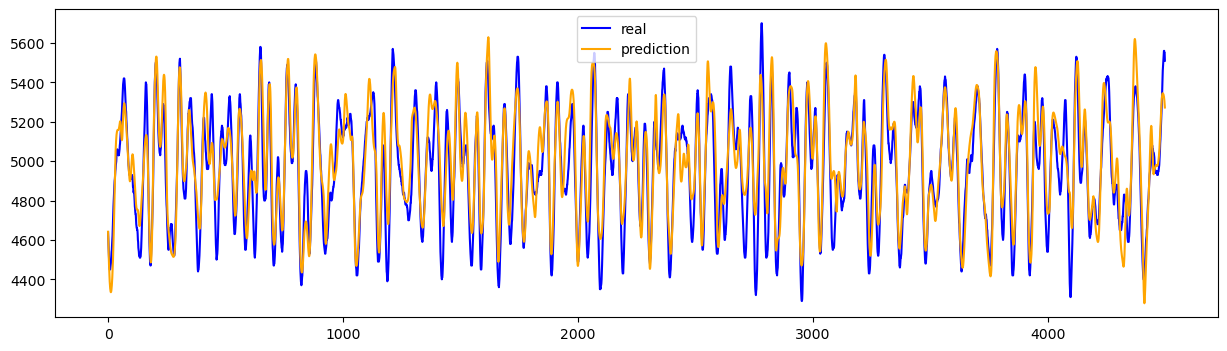

In [22]:
fan_force250_real1,fan_force250_pre1 = FanGuiHua_force2(valid50_y_Force2,N_pre50_Y_Force2)

np.savetxt('force2500_步长10_GRU.csv',np.hstack((fan_force250_real1,fan_force250_pre1)),delimiter=',')

In [23]:
RNSE(valid50_y_Force1,N_pre50_Y_Force1)
Acc(valid50_y_Force1,N_pre50_Y_Force1)

RMSE(sklearn): 0.103380821989954
Acc: 0.9995106690429205


In [24]:
RNSE(valid50_y_Force2,N_pre50_Y_Force2)
Acc(valid50_y_Force2,N_pre50_Y_Force2)

RMSE(sklearn): 0.16945552798043864
Acc: 0.9154832039256406


#### 系泊缆力联合预测（时间窗500输出；步长20）

In [25]:
# 未来运动预测模型建立
train_heave50_x2, train_heave50_y2, valid_heave50_x2, valid_heave50_y2 = split_train_valid(heave50_x2,heave50_y2, 4500, 7500, 12000)
heave50_model2, heave50_history2, pre_heave50_Y2 = Model_GRU(train_heave50_x2, train_heave50_y2, valid_heave50_x2, valid_heave50_y2, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x2, train_surge50_y2, valid_surge50_x2, valid_surge50_y2 = split_train_valid(surge50_x2,surge50_y2, 4200, 7500, 12000)
surge50_model2, surge50_history2, pre_surge50_Y2 = Model_GRU(train_surge50_x2, train_surge50_y2, valid_surge50_x2, valid_surge50_y2, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x2, train_pitch50_y2, valid_pitch50_x2, valid_pitch50_y2 = split_train_valid(pitch50_x2,pitch50_y2, 4500, 7500, 12000)
pitch50_model2, pitch50_history2, pre_pitch50_Y2 = Model_GRU(train_pitch50_x2, train_pitch50_y2, valid_pitch50_x2, valid_pitch50_y2, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

E:\Anaconda\envs\TensorFlow_env\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


Epoch 1/30
60/60 - 18s - loss: 0.0890 - val_loss: 0.0846 - 18s/epoch - 292ms/step
Epoch 2/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 143ms/step
Epoch 3/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 154ms/step
Epoch 4/30
60/60 - 8s - loss: 0.0884 - val_loss: 0.0846 - 8s/epoch - 141ms/step
Epoch 5/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 143ms/step
Epoch 6/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 142ms/step
Epoch 7/30
60/60 - 8s - loss: 0.0884 - val_loss: 0.0846 - 8s/epoch - 140ms/step
Epoch 8/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 146ms/step
Epoch 9/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 142ms/step
Epoch 10/30
60/60 - 8s - loss: 0.0884 - val_loss: 0.0846 - 8s/epoch - 140ms/step
Epoch 11/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 150ms/step
Epoch 12/30
60/60 - 8s - loss: 0.0884 - val_loss: 0.0846 - 8s/epoch - 141ms/step
Epoch 13/30
60/60 - 8s - loss: 0.08

Epoch 21/30
60/60 - 9s - loss: 0.0722 - val_loss: 0.0701 - 9s/epoch - 146ms/step
Epoch 22/30
60/60 - 9s - loss: 0.0722 - val_loss: 0.0701 - 9s/epoch - 155ms/step
Epoch 23/30
60/60 - 9s - loss: 0.0722 - val_loss: 0.0701 - 9s/epoch - 150ms/step
Epoch 24/30
60/60 - 8s - loss: 0.0722 - val_loss: 0.0701 - 8s/epoch - 139ms/step
Epoch 25/30
60/60 - 9s - loss: 0.0722 - val_loss: 0.0701 - 9s/epoch - 149ms/step
Epoch 26/30
60/60 - 8s - loss: 0.0722 - val_loss: 0.0701 - 8s/epoch - 140ms/step
Epoch 27/30
60/60 - 8s - loss: 0.0722 - val_loss: 0.0701 - 8s/epoch - 139ms/step
Epoch 28/30
60/60 - 9s - loss: 0.0722 - val_loss: 0.0701 - 9s/epoch - 142ms/step
Epoch 29/30
60/60 - 9s - loss: 0.0722 - val_loss: 0.0701 - 9s/epoch - 143ms/step
Epoch 30/30
60/60 - 8s - loss: 0.0722 - val_loss: 0.0701 - 8s/epoch - 139ms/step
Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_5 (GRU)                 (None, 

In [26]:
pretrain_heave50_Y2 = heave50_model2.predict(train_heave50_x2)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y2 = surge50_model2.predict(train_surge50_x2[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y2 = pitch50_model2.predict(train_pitch50_x2)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y2.shape)
print(pretrain_surge50_Y2.shape)
print(pretrain_pitch50_Y2.shape)

94/94 [==============================] - 3s 27ms/step
(3000, 500, 1)
(3000, 500, 1)
(3000, 500, 1)


In [27]:
# 输入50步长输出2步长Force1
force150_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3490:,:], 4, 519)
force150_x2,force150_y2 = split_sequence(force150_scaled2, 500)
# print(force150_x2.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [28]:
train_force150_x2, train_force150_y2, valid_force150_x2, valid_force150_y2 = split_train_valid(force150_x2,force150_y2, 4500, 7500, 12000)
train50_x2_Force1, valid50_x2_Force1 = np.hstack((pretrain_heave50_Y2, pretrain_surge50_Y2, pretrain_pitch50_Y2)), np.hstack((pre_heave50_Y2, pre_surge50_Y2, pre_pitch50_Y2))
train50_y2_Force1, valid50_y2_Force1 = train_force150_y2, valid_force150_y2

In [29]:
N_model50_2_Force1, N_history50_2_Force1, N_pre50_train_Y2_Force1, N_pre50_Y2_Force1 = Model_NN(train50_x2_Force1, train50_y2_Force1, valid50_x2_Force1, valid50_y2_Force1, lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000
12/12 - 2s - loss: 0.2780 - val_loss: 0.0933 - 2s/epoch - 202ms/step
Epoch 2/1000
12/12 - 0s - loss: 0.0958 - val_loss: 0.0646 - 137ms/epoch - 11ms/step
Epoch 3/1000
12/12 - 0s - loss: 0.0732 - val_loss: 0.0657 - 122ms/epoch - 10ms/step
Epoch 4/1000
12/12 - 0s - loss: 0.0656 - val_loss: 0.0596 - 123ms/epoch - 10ms/step
Epoch 5/1000
12/12 - 0s - loss: 0.0613 - val_loss: 0.0552 - 124ms/epoch - 10ms/step
Epoch 6/1000
12/12 - 0s - loss: 0.0556 - val_loss: 0.0491 - 127ms/epoch - 11ms/step
Epoch 7/1000
12/12 - 0s - loss: 0.0479 - val_loss: 0.0413 - 134ms/epoch - 11ms/step
Epoch 8/1000
12/12 - 0s - loss: 0.0400 - val_loss: 0.0338 - 120ms/epoch - 10ms/step
Epoch 9/1000
12/12 - 0s - loss: 0.0361 - val_loss: 0.0312 - 128ms/epoch - 11ms/step
Epoch 10/1000
12/12 - 0s - loss: 0.0306 - val_loss: 0.0270 - 125ms/epoch - 10ms/step
Epoch 11/1000
12/12 - 0s - loss: 0.0282 - val_loss: 0.0263 - 124ms/epoch - 10ms/step
Epoch 12/1000
12/12 - 0s - loss: 0.0285 - val_loss: 0.0257 - 160ms/epoch - 1

Epoch 99/1000
12/12 - 0s - loss: 0.0157 - val_loss: 0.0158 - 105ms/epoch - 9ms/step
Epoch 100/1000
12/12 - 0s - loss: 0.0156 - val_loss: 0.0158 - 105ms/epoch - 9ms/step
Epoch 101/1000
12/12 - 0s - loss: 0.0156 - val_loss: 0.0158 - 116ms/epoch - 10ms/step
Epoch 102/1000
12/12 - 0s - loss: 0.0156 - val_loss: 0.0158 - 111ms/epoch - 9ms/step
Epoch 103/1000
12/12 - 0s - loss: 0.0156 - val_loss: 0.0158 - 113ms/epoch - 9ms/step
Epoch 104/1000
12/12 - 0s - loss: 0.0155 - val_loss: 0.0158 - 106ms/epoch - 9ms/step
Epoch 105/1000
12/12 - 0s - loss: 0.0155 - val_loss: 0.0157 - 106ms/epoch - 9ms/step
Epoch 106/1000
12/12 - 0s - loss: 0.0155 - val_loss: 0.0157 - 107ms/epoch - 9ms/step
Epoch 107/1000
12/12 - 0s - loss: 0.0155 - val_loss: 0.0157 - 107ms/epoch - 9ms/step
Epoch 108/1000
12/12 - 0s - loss: 0.0154 - val_loss: 0.0157 - 109ms/epoch - 9ms/step
Epoch 109/1000
12/12 - 0s - loss: 0.0154 - val_loss: 0.0157 - 113ms/epoch - 9ms/step
Epoch 110/1000
12/12 - 0s - loss: 0.0154 - val_loss: 0.0157 - 117

Epoch 196/1000
12/12 - 0s - loss: 0.0138 - val_loss: 0.0143 - 107ms/epoch - 9ms/step
Epoch 197/1000
12/12 - 0s - loss: 0.0138 - val_loss: 0.0143 - 115ms/epoch - 10ms/step
Epoch 198/1000
12/12 - 0s - loss: 0.0137 - val_loss: 0.0143 - 113ms/epoch - 9ms/step
Epoch 199/1000
12/12 - 0s - loss: 0.0137 - val_loss: 0.0143 - 106ms/epoch - 9ms/step
Epoch 200/1000
12/12 - 0s - loss: 0.0137 - val_loss: 0.0143 - 105ms/epoch - 9ms/step
Epoch 201/1000
12/12 - 0s - loss: 0.0137 - val_loss: 0.0142 - 105ms/epoch - 9ms/step
Epoch 202/1000
12/12 - 0s - loss: 0.0137 - val_loss: 0.0142 - 108ms/epoch - 9ms/step
Epoch 203/1000
12/12 - 0s - loss: 0.0137 - val_loss: 0.0142 - 107ms/epoch - 9ms/step
Epoch 204/1000
12/12 - 0s - loss: 0.0137 - val_loss: 0.0142 - 113ms/epoch - 9ms/step
Epoch 205/1000
12/12 - 0s - loss: 0.0136 - val_loss: 0.0142 - 108ms/epoch - 9ms/step
Epoch 206/1000
12/12 - 0s - loss: 0.0136 - val_loss: 0.0142 - 113ms/epoch - 9ms/step
Epoch 207/1000
12/12 - 0s - loss: 0.0136 - val_loss: 0.0141 - 11

Epoch 293/1000
12/12 - 0s - loss: 0.0117 - val_loss: 0.0118 - 125ms/epoch - 10ms/step
Epoch 294/1000
12/12 - 0s - loss: 0.0117 - val_loss: 0.0117 - 117ms/epoch - 10ms/step
Epoch 295/1000
12/12 - 0s - loss: 0.0117 - val_loss: 0.0117 - 107ms/epoch - 9ms/step
Epoch 296/1000
12/12 - 0s - loss: 0.0117 - val_loss: 0.0116 - 111ms/epoch - 9ms/step
Epoch 297/1000
12/12 - 0s - loss: 0.0117 - val_loss: 0.0117 - 125ms/epoch - 10ms/step
Epoch 298/1000
12/12 - 0s - loss: 0.0116 - val_loss: 0.0116 - 113ms/epoch - 9ms/step
Epoch 299/1000
12/12 - 0s - loss: 0.0116 - val_loss: 0.0116 - 109ms/epoch - 9ms/step
Epoch 300/1000
12/12 - 0s - loss: 0.0116 - val_loss: 0.0115 - 106ms/epoch - 9ms/step
Epoch 301/1000
12/12 - 0s - loss: 0.0116 - val_loss: 0.0115 - 121ms/epoch - 10ms/step
Epoch 302/1000
12/12 - 0s - loss: 0.0116 - val_loss: 0.0115 - 121ms/epoch - 10ms/step
Epoch 303/1000
12/12 - 0s - loss: 0.0116 - val_loss: 0.0114 - 115ms/epoch - 10ms/step
Epoch 304/1000
12/12 - 0s - loss: 0.0116 - val_loss: 0.0114

Epoch 389/1000
12/12 - 0s - loss: 0.0109 - val_loss: 0.0102 - 128ms/epoch - 11ms/step
Epoch 390/1000
12/12 - 1s - loss: 0.0109 - val_loss: 0.0102 - 543ms/epoch - 45ms/step
Epoch 391/1000
12/12 - 0s - loss: 0.0109 - val_loss: 0.0102 - 160ms/epoch - 13ms/step
Epoch 392/1000
12/12 - 0s - loss: 0.0109 - val_loss: 0.0102 - 138ms/epoch - 11ms/step
Epoch 393/1000
12/12 - 0s - loss: 0.0109 - val_loss: 0.0102 - 127ms/epoch - 11ms/step
Epoch 394/1000
12/12 - 0s - loss: 0.0109 - val_loss: 0.0102 - 121ms/epoch - 10ms/step
Epoch 395/1000
12/12 - 0s - loss: 0.0109 - val_loss: 0.0101 - 108ms/epoch - 9ms/step
Epoch 396/1000
12/12 - 0s - loss: 0.0109 - val_loss: 0.0101 - 108ms/epoch - 9ms/step
Epoch 397/1000
12/12 - 0s - loss: 0.0109 - val_loss: 0.0101 - 107ms/epoch - 9ms/step
Epoch 398/1000
12/12 - 0s - loss: 0.0109 - val_loss: 0.0101 - 114ms/epoch - 9ms/step
Epoch 399/1000
12/12 - 0s - loss: 0.0109 - val_loss: 0.0101 - 106ms/epoch - 9ms/step
Epoch 400/1000
12/12 - 0s - loss: 0.0109 - val_loss: 0.0101

...

Epoch 581/1000
12/12 - 0s - loss: 0.0130 - val_loss: 0.0128 - 117ms/epoch - 10ms/step
Epoch 582/1000
12/12 - 0s - loss: 0.0104 - val_loss: 0.0116 - 115ms/epoch - 10ms/step
Epoch 583/1000
12/12 - 0s - loss: 0.0115 - val_loss: 0.0126 - 116ms/epoch - 10ms/step
Epoch 584/1000
12/12 - 0s - loss: 0.0129 - val_loss: 0.0127 - 123ms/epoch - 10ms/step
Epoch 585/1000
12/12 - 0s - loss: 0.0104 - val_loss: 0.0118 - 135ms/epoch - 11ms/step
Epoch 586/1000
12/12 - 0s - loss: 0.0116 - val_loss: 0.0123 - 124ms/epoch - 10ms/step
Epoch 587/1000
12/12 - 0s - loss: 0.0127 - val_loss: 0.0126 - 120ms/epoch - 10ms/step
Epoch 588/1000
12/12 - 0s - loss: 0.0103 - val_loss: 0.0120 - 136ms/epoch - 11ms/step
Epoch 589/1000
12/12 - 0s - loss: 0.0118 - val_loss: 0.0119 - 118ms/epoch - 10ms/step
Epoch 590/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0124 - 111ms/epoch - 9ms/step
Epoch 591/1000
12/12 - 0s - loss: 0.0102 - val_loss: 0.0122 - 133ms/epoch - 11ms/step
Epoch 592/1000
12/12 - 0s - loss: 0.0119 - val_loss: 0.

Epoch 677/1000
12/12 - 0s - loss: 0.0101 - val_loss: 0.0121 - 116ms/epoch - 10ms/step
Epoch 678/1000
12/12 - 0s - loss: 0.0101 - val_loss: 0.0172 - 123ms/epoch - 10ms/step
Epoch 679/1000
12/12 - 0s - loss: 0.0114 - val_loss: 0.0139 - 116ms/epoch - 10ms/step
Epoch 680/1000
12/12 - 0s - loss: 0.0116 - val_loss: 0.0141 - 126ms/epoch - 10ms/step
Epoch 681/1000
12/12 - 0s - loss: 0.0145 - val_loss: 0.0108 - 114ms/epoch - 9ms/step
Epoch 682/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0179 - 114ms/epoch - 9ms/step
Epoch 683/1000
12/12 - 0s - loss: 0.0159 - val_loss: 0.0110 - 116ms/epoch - 10ms/step
Epoch 684/1000
12/12 - 0s - loss: 0.0119 - val_loss: 0.0142 - 114ms/epoch - 9ms/step
Epoch 685/1000
12/12 - 0s - loss: 0.0122 - val_loss: 0.0111 - 116ms/epoch - 10ms/step
Epoch 686/1000
12/12 - 0s - loss: 0.0107 - val_loss: 0.0112 - 117ms/epoch - 10ms/step
Epoch 687/1000
12/12 - 0s - loss: 0.0111 - val_loss: 0.0115 - 118ms/epoch - 10ms/step
Epoch 688/1000
12/12 - 0s - loss: 0.0109 - val_loss: 0.01

Epoch 773/1000
12/12 - 0s - loss: 0.0123 - val_loss: 0.0123 - 116ms/epoch - 10ms/step
Epoch 774/1000
12/12 - 0s - loss: 0.0100 - val_loss: 0.0126 - 113ms/epoch - 9ms/step
Epoch 775/1000
12/12 - 0s - loss: 0.0139 - val_loss: 0.0123 - 117ms/epoch - 10ms/step
Epoch 776/1000
12/12 - 0s - loss: 0.0132 - val_loss: 0.0151 - 114ms/epoch - 9ms/step
Epoch 777/1000
12/12 - 0s - loss: 0.0172 - val_loss: 0.0176 - 129ms/epoch - 11ms/step
Epoch 778/1000
12/12 - 0s - loss: 0.0134 - val_loss: 0.0190 - 114ms/epoch - 9ms/step
Epoch 779/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.0131 - 118ms/epoch - 10ms/step
Epoch 780/1000
12/12 - 0s - loss: 0.0099 - val_loss: 0.0143 - 118ms/epoch - 10ms/step
Epoch 781/1000
12/12 - 0s - loss: 0.0106 - val_loss: 0.0112 - 114ms/epoch - 9ms/step
Epoch 782/1000
12/12 - 0s - loss: 0.0088 - val_loss: 0.0125 - 117ms/epoch - 10ms/step
Epoch 783/1000
12/12 - 0s - loss: 0.0101 - val_loss: 0.0108 - 123ms/epoch - 10ms/step
Epoch 784/1000
12/12 - 0s - loss: 0.0095 - val_loss: 0.010

Epoch 869/1000
12/12 - 0s - loss: 0.0093 - val_loss: 0.0157 - 116ms/epoch - 10ms/step
Epoch 870/1000
12/12 - 0s - loss: 0.0105 - val_loss: 0.0117 - 116ms/epoch - 10ms/step
Epoch 871/1000
12/12 - 0s - loss: 0.0099 - val_loss: 0.0164 - 116ms/epoch - 10ms/step
Epoch 872/1000
12/12 - 0s - loss: 0.0108 - val_loss: 0.0118 - 128ms/epoch - 11ms/step
Epoch 873/1000
12/12 - 0s - loss: 0.0102 - val_loss: 0.0142 - 116ms/epoch - 10ms/step
Epoch 874/1000
12/12 - 0s - loss: 0.0093 - val_loss: 0.0115 - 116ms/epoch - 10ms/step
Epoch 875/1000
12/12 - 0s - loss: 0.0093 - val_loss: 0.0148 - 115ms/epoch - 10ms/step
Epoch 876/1000
12/12 - 0s - loss: 0.0107 - val_loss: 0.0117 - 116ms/epoch - 10ms/step
Epoch 877/1000
12/12 - 0s - loss: 0.0097 - val_loss: 0.0155 - 117ms/epoch - 10ms/step
Epoch 878/1000
12/12 - 0s - loss: 0.0101 - val_loss: 0.0120 - 116ms/epoch - 10ms/step
Epoch 879/1000
12/12 - 0s - loss: 0.0099 - val_loss: 0.0149 - 125ms/epoch - 10ms/step
Epoch 880/1000
12/12 - 0s - loss: 0.0095 - val_loss: 0

Epoch 965/1000
12/12 - 0s - loss: 0.0088 - val_loss: 0.0187 - 126ms/epoch - 10ms/step
Epoch 966/1000
12/12 - 0s - loss: 0.0092 - val_loss: 0.0201 - 114ms/epoch - 9ms/step
Epoch 967/1000
12/12 - 0s - loss: 0.0097 - val_loss: 0.0210 - 116ms/epoch - 10ms/step
Epoch 968/1000
12/12 - 0s - loss: 0.0103 - val_loss: 0.0214 - 116ms/epoch - 10ms/step
Epoch 969/1000
12/12 - 0s - loss: 0.0108 - val_loss: 0.0205 - 122ms/epoch - 10ms/step
Epoch 970/1000
12/12 - 0s - loss: 0.0115 - val_loss: 0.0168 - 112ms/epoch - 9ms/step
Epoch 971/1000
12/12 - 0s - loss: 0.0117 - val_loss: 0.0135 - 115ms/epoch - 10ms/step
Epoch 972/1000
12/12 - 0s - loss: 0.0123 - val_loss: 0.0164 - 115ms/epoch - 10ms/step
Epoch 973/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0141 - 116ms/epoch - 10ms/step
Epoch 974/1000
12/12 - 0s - loss: 0.0128 - val_loss: 0.0149 - 127ms/epoch - 11ms/step
Epoch 975/1000
12/12 - 0s - loss: 0.0099 - val_loss: 0.0137 - 116ms/epoch - 10ms/step
Epoch 976/1000
12/12 - 0s - loss: 0.0101 - val_loss: 0.0

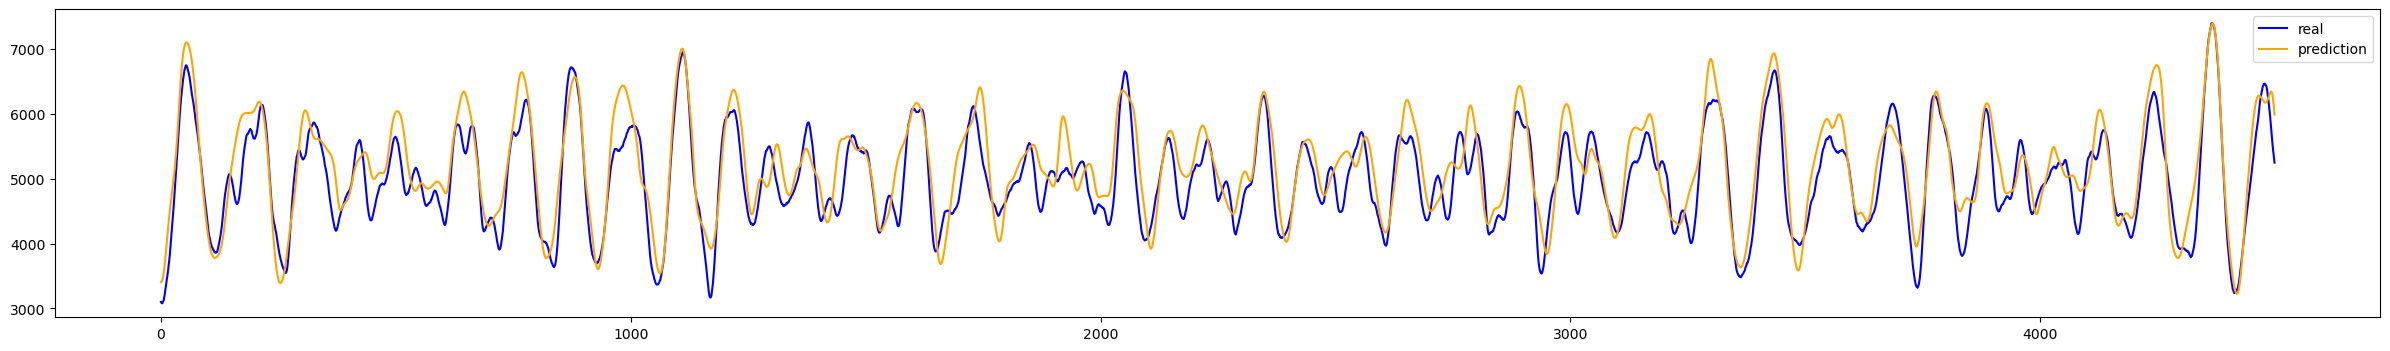

In [30]:
fan_force150_real2,fan_force150_pre2 = FanGuiHua_force1(valid50_y2_Force1,N_pre50_Y2_Force1)

np.savetxt('force1500_步长20_GRU.csv',np.hstack((fan_force150_real2,fan_force150_pre2)),delimiter=',')

In [31]:
# 输入50步长输出2步长Force2
force250_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[3490:,:], 4, 519)
force250_x2,force250_y2 = split_sequence(force250_scaled2, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [32]:
train_force250_x2, train_force250_y2, valid_force250_x2, valid_force250_y2 = split_train_valid(force250_x2,force250_y2, 4500, 7500, 12000)
train50_x2_Force2, valid50_x2_Force2 = np.hstack((pretrain_heave50_Y2, pretrain_surge50_Y2, pretrain_pitch50_Y2)), np.hstack((pre_heave50_Y2, pre_surge50_Y2, pre_pitch50_Y2))
train50_y2_Force2, valid50_y2_Force2 = train_force250_y2, valid_force250_y2

In [33]:
N_model50_2_Force2, N_history50_2_Force2, N_pre50_train_Y2_Force2, N_pre50_Y2_Force2 = Model_NN(train50_x2_Force2, train50_y2_Force2, valid50_x2_Force2, valid50_y2_Force2,lr=0.01, epochs=1000, batch_size=256)

E:\Anaconda\envs\TensorFlow_env\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


Epoch 1/1000
12/12 - 2s - loss: 0.1709 - val_loss: 0.1286 - 2s/epoch - 177ms/step
Epoch 2/1000
12/12 - 0s - loss: 0.1258 - val_loss: 0.1263 - 146ms/epoch - 12ms/step
Epoch 3/1000
12/12 - 0s - loss: 0.1193 - val_loss: 0.1276 - 140ms/epoch - 12ms/step
Epoch 4/1000
12/12 - 0s - loss: 0.1150 - val_loss: 0.1221 - 136ms/epoch - 11ms/step
Epoch 5/1000
12/12 - 0s - loss: 0.1093 - val_loss: 0.1134 - 142ms/epoch - 12ms/step
Epoch 6/1000
12/12 - 0s - loss: 0.1045 - val_loss: 0.1077 - 129ms/epoch - 11ms/step
Epoch 7/1000
12/12 - 0s - loss: 0.0988 - val_loss: 0.1118 - 131ms/epoch - 11ms/step
Epoch 8/1000
12/12 - 0s - loss: 0.1025 - val_loss: 0.1034 - 126ms/epoch - 10ms/step
Epoch 9/1000
12/12 - 0s - loss: 0.0987 - val_loss: 0.1078 - 129ms/epoch - 11ms/step
Epoch 10/1000
12/12 - 0s - loss: 0.0927 - val_loss: 0.1071 - 133ms/epoch - 11ms/step
Epoch 11/1000
12/12 - 0s - loss: 0.0969 - val_loss: 0.0968 - 133ms/epoch - 11ms/step
Epoch 12/1000
12/12 - 0s - loss: 0.0960 - val_loss: 0.1040 - 144ms/epoch - 1

Epoch 98/1000
12/12 - 0s - loss: 0.0426 - val_loss: 0.0704 - 120ms/epoch - 10ms/step
Epoch 99/1000
12/12 - 0s - loss: 0.0428 - val_loss: 0.0656 - 118ms/epoch - 10ms/step
Epoch 100/1000
12/12 - 0s - loss: 0.0423 - val_loss: 0.0707 - 118ms/epoch - 10ms/step
Epoch 101/1000
12/12 - 0s - loss: 0.0427 - val_loss: 0.0652 - 118ms/epoch - 10ms/step
Epoch 102/1000
12/12 - 0s - loss: 0.0421 - val_loss: 0.0713 - 118ms/epoch - 10ms/step
Epoch 103/1000
12/12 - 0s - loss: 0.0425 - val_loss: 0.0651 - 118ms/epoch - 10ms/step
Epoch 104/1000
12/12 - 0s - loss: 0.0419 - val_loss: 0.0722 - 117ms/epoch - 10ms/step
Epoch 105/1000
12/12 - 0s - loss: 0.0424 - val_loss: 0.0658 - 120ms/epoch - 10ms/step
Epoch 106/1000
12/12 - 0s - loss: 0.0418 - val_loss: 0.0737 - 115ms/epoch - 10ms/step
Epoch 107/1000
12/12 - 0s - loss: 0.0423 - val_loss: 0.0684 - 117ms/epoch - 10ms/step
Epoch 108/1000
12/12 - 0s - loss: 0.0416 - val_loss: 0.0772 - 118ms/epoch - 10ms/step
Epoch 109/1000
12/12 - 0s - loss: 0.0421 - val_loss: 0.0

Epoch 194/1000
12/12 - 0s - loss: 0.0363 - val_loss: 0.0448 - 115ms/epoch - 10ms/step
Epoch 195/1000
12/12 - 0s - loss: 0.0318 - val_loss: 0.0638 - 127ms/epoch - 11ms/step
Epoch 196/1000
12/12 - 0s - loss: 0.0336 - val_loss: 0.0548 - 128ms/epoch - 11ms/step
Epoch 197/1000
12/12 - 0s - loss: 0.0365 - val_loss: 0.0439 - 137ms/epoch - 11ms/step
Epoch 198/1000
12/12 - 0s - loss: 0.0311 - val_loss: 0.0650 - 131ms/epoch - 11ms/step
Epoch 199/1000
12/12 - 0s - loss: 0.0340 - val_loss: 0.0515 - 136ms/epoch - 11ms/step
Epoch 200/1000
12/12 - 0s - loss: 0.0364 - val_loss: 0.0430 - 126ms/epoch - 10ms/step
Epoch 201/1000
12/12 - 0s - loss: 0.0310 - val_loss: 0.0659 - 144ms/epoch - 12ms/step
Epoch 202/1000
12/12 - 0s - loss: 0.0339 - val_loss: 0.0509 - 135ms/epoch - 11ms/step
Epoch 203/1000
12/12 - 0s - loss: 0.0362 - val_loss: 0.0418 - 139ms/epoch - 12ms/step
Epoch 204/1000
12/12 - 0s - loss: 0.0306 - val_loss: 0.0631 - 118ms/epoch - 10ms/step
Epoch 205/1000
12/12 - 0s - loss: 0.0332 - val_loss: 0

Epoch 290/1000
12/12 - 0s - loss: 0.0283 - val_loss: 0.0379 - 125ms/epoch - 10ms/step
Epoch 291/1000
12/12 - 0s - loss: 0.0343 - val_loss: 0.0821 - 117ms/epoch - 10ms/step
Epoch 292/1000
12/12 - 0s - loss: 0.0435 - val_loss: 0.0374 - 120ms/epoch - 10ms/step
Epoch 293/1000
12/12 - 0s - loss: 0.0303 - val_loss: 0.0509 - 118ms/epoch - 10ms/step
Epoch 294/1000
12/12 - 0s - loss: 0.0293 - val_loss: 0.0396 - 119ms/epoch - 10ms/step
Epoch 295/1000
12/12 - 0s - loss: 0.0305 - val_loss: 0.0305 - 117ms/epoch - 10ms/step
Epoch 296/1000
12/12 - 0s - loss: 0.0244 - val_loss: 0.0355 - 122ms/epoch - 10ms/step
Epoch 297/1000
12/12 - 0s - loss: 0.0278 - val_loss: 0.0379 - 127ms/epoch - 11ms/step
Epoch 298/1000
12/12 - 0s - loss: 0.0309 - val_loss: 0.0636 - 117ms/epoch - 10ms/step
Epoch 299/1000
12/12 - 0s - loss: 0.0361 - val_loss: 0.0329 - 118ms/epoch - 10ms/step
Epoch 300/1000
12/12 - 0s - loss: 0.0246 - val_loss: 0.0388 - 117ms/epoch - 10ms/step
Epoch 301/1000
12/12 - 0s - loss: 0.0292 - val_loss: 0

...

Epoch 578/1000
12/12 - 0s - loss: 0.0527 - val_loss: 0.0632 - 117ms/epoch - 10ms/step
Epoch 579/1000
12/12 - 0s - loss: 0.0370 - val_loss: 0.0361 - 117ms/epoch - 10ms/step
Epoch 580/1000
12/12 - 0s - loss: 0.0284 - val_loss: 0.0337 - 118ms/epoch - 10ms/step
Epoch 581/1000
12/12 - 0s - loss: 0.0467 - val_loss: 0.0633 - 118ms/epoch - 10ms/step
Epoch 582/1000
12/12 - 0s - loss: 0.0455 - val_loss: 0.0392 - 129ms/epoch - 11ms/step
Epoch 583/1000
12/12 - 0s - loss: 0.0280 - val_loss: 0.0373 - 118ms/epoch - 10ms/step
Epoch 584/1000
12/12 - 0s - loss: 0.0372 - val_loss: 0.0428 - 117ms/epoch - 10ms/step
Epoch 585/1000
12/12 - 0s - loss: 0.0530 - val_loss: 0.0568 - 118ms/epoch - 10ms/step
Epoch 586/1000
12/12 - 0s - loss: 0.0350 - val_loss: 0.0388 - 116ms/epoch - 10ms/step
Epoch 587/1000
12/12 - 0s - loss: 0.0286 - val_loss: 0.0340 - 124ms/epoch - 10ms/step
Epoch 588/1000
12/12 - 0s - loss: 0.0452 - val_loss: 0.0603 - 119ms/epoch - 10ms/step
Epoch 589/1000
12/12 - 0s - loss: 0.0441 - val_loss: 0

Epoch 674/1000
12/12 - 0s - loss: 0.0278 - val_loss: 0.0377 - 122ms/epoch - 10ms/step
Epoch 675/1000
12/12 - 0s - loss: 0.0216 - val_loss: 0.0401 - 117ms/epoch - 10ms/step
Epoch 676/1000
12/12 - 0s - loss: 0.0196 - val_loss: 0.0342 - 126ms/epoch - 10ms/step
Epoch 677/1000
12/12 - 0s - loss: 0.0182 - val_loss: 0.0352 - 135ms/epoch - 11ms/step
Epoch 678/1000
12/12 - 0s - loss: 0.0176 - val_loss: 0.0356 - 118ms/epoch - 10ms/step
Epoch 679/1000
12/12 - 0s - loss: 0.0184 - val_loss: 0.0374 - 118ms/epoch - 10ms/step
Epoch 680/1000
12/12 - 0s - loss: 0.0190 - val_loss: 0.0372 - 117ms/epoch - 10ms/step
Epoch 681/1000
12/12 - 0s - loss: 0.0189 - val_loss: 0.0377 - 121ms/epoch - 10ms/step
Epoch 682/1000
12/12 - 0s - loss: 0.0192 - val_loss: 0.0390 - 134ms/epoch - 11ms/step
Epoch 683/1000
12/12 - 0s - loss: 0.0198 - val_loss: 0.0398 - 116ms/epoch - 10ms/step
Epoch 684/1000
12/12 - 0s - loss: 0.0200 - val_loss: 0.0404 - 127ms/epoch - 11ms/step
Epoch 685/1000
12/12 - 0s - loss: 0.0204 - val_loss: 0

Epoch 770/1000
12/12 - 0s - loss: 0.0173 - val_loss: 0.0320 - 150ms/epoch - 12ms/step
Epoch 771/1000
12/12 - 0s - loss: 0.0171 - val_loss: 0.0322 - 128ms/epoch - 11ms/step
Epoch 772/1000
12/12 - 0s - loss: 0.0169 - val_loss: 0.0324 - 117ms/epoch - 10ms/step
Epoch 773/1000
12/12 - 0s - loss: 0.0167 - val_loss: 0.0325 - 117ms/epoch - 10ms/step
Epoch 774/1000
12/12 - 0s - loss: 0.0166 - val_loss: 0.0327 - 117ms/epoch - 10ms/step
Epoch 775/1000
12/12 - 0s - loss: 0.0164 - val_loss: 0.0328 - 121ms/epoch - 10ms/step
Epoch 776/1000
12/12 - 0s - loss: 0.0162 - val_loss: 0.0329 - 130ms/epoch - 11ms/step
Epoch 777/1000
12/12 - 0s - loss: 0.0160 - val_loss: 0.0330 - 117ms/epoch - 10ms/step
Epoch 778/1000
12/12 - 0s - loss: 0.0159 - val_loss: 0.0331 - 117ms/epoch - 10ms/step
Epoch 779/1000
12/12 - 0s - loss: 0.0158 - val_loss: 0.0332 - 118ms/epoch - 10ms/step
Epoch 780/1000
12/12 - 0s - loss: 0.0157 - val_loss: 0.0333 - 119ms/epoch - 10ms/step
Epoch 781/1000
12/12 - 0s - loss: 0.0156 - val_loss: 0

Epoch 866/1000
12/12 - 0s - loss: 0.0184 - val_loss: 0.0399 - 119ms/epoch - 10ms/step
Epoch 867/1000
12/12 - 0s - loss: 0.0174 - val_loss: 0.0391 - 118ms/epoch - 10ms/step
Epoch 868/1000
12/12 - 0s - loss: 0.0170 - val_loss: 0.0390 - 119ms/epoch - 10ms/step
Epoch 869/1000
12/12 - 0s - loss: 0.0169 - val_loss: 0.0408 - 118ms/epoch - 10ms/step
Epoch 870/1000
12/12 - 0s - loss: 0.0176 - val_loss: 0.0429 - 120ms/epoch - 10ms/step
Epoch 871/1000
12/12 - 0s - loss: 0.0181 - val_loss: 0.0452 - 117ms/epoch - 10ms/step
Epoch 872/1000
12/12 - 0s - loss: 0.0191 - val_loss: 0.0464 - 130ms/epoch - 11ms/step
Epoch 873/1000
12/12 - 0s - loss: 0.0212 - val_loss: 0.0421 - 124ms/epoch - 10ms/step
Epoch 874/1000
12/12 - 0s - loss: 0.0275 - val_loss: 0.0437 - 118ms/epoch - 10ms/step
Epoch 875/1000
12/12 - 0s - loss: 0.0335 - val_loss: 0.0421 - 118ms/epoch - 10ms/step
Epoch 876/1000
12/12 - 0s - loss: 0.0411 - val_loss: 0.0551 - 120ms/epoch - 10ms/step
Epoch 877/1000
12/12 - 0s - loss: 0.0251 - val_loss: 0

Epoch 962/1000
12/12 - 0s - loss: 0.0173 - val_loss: 0.0519 - 118ms/epoch - 10ms/step
Epoch 963/1000
12/12 - 0s - loss: 0.0187 - val_loss: 0.0507 - 118ms/epoch - 10ms/step
Epoch 964/1000
12/12 - 0s - loss: 0.0191 - val_loss: 0.0432 - 117ms/epoch - 10ms/step
Epoch 965/1000
12/12 - 0s - loss: 0.0304 - val_loss: 0.0601 - 117ms/epoch - 10ms/step
Epoch 966/1000
12/12 - 0s - loss: 0.0262 - val_loss: 0.0398 - 123ms/epoch - 10ms/step
Epoch 967/1000
12/12 - 0s - loss: 0.0159 - val_loss: 0.0417 - 117ms/epoch - 10ms/step
Epoch 968/1000
12/12 - 0s - loss: 0.0163 - val_loss: 0.0376 - 118ms/epoch - 10ms/step
Epoch 969/1000
12/12 - 0s - loss: 0.0159 - val_loss: 0.0391 - 119ms/epoch - 10ms/step
Epoch 970/1000
12/12 - 0s - loss: 0.0197 - val_loss: 0.0462 - 117ms/epoch - 10ms/step
Epoch 971/1000
12/12 - 0s - loss: 0.0186 - val_loss: 0.0428 - 116ms/epoch - 10ms/step
Epoch 972/1000
12/12 - 0s - loss: 0.0150 - val_loss: 0.0406 - 118ms/epoch - 10ms/step
Epoch 973/1000
12/12 - 0s - loss: 0.0121 - val_loss: 0

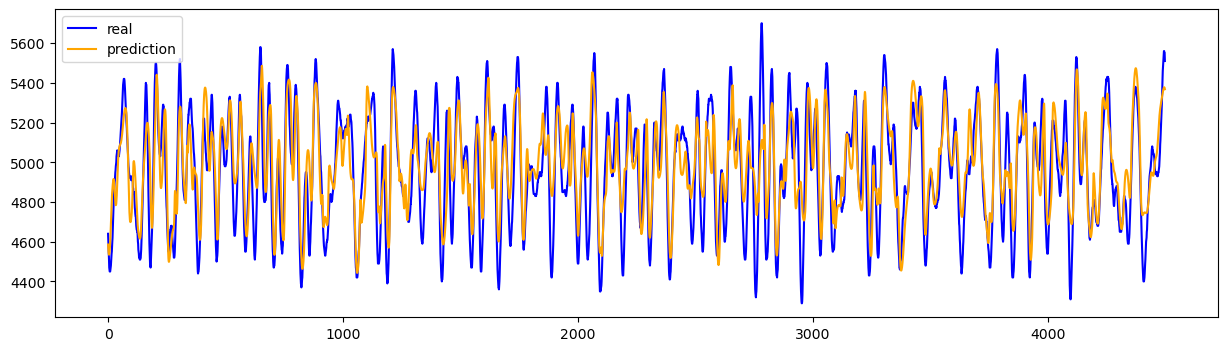

In [34]:
fan_force250_real2,fan_force250_pre2 = FanGuiHua_force2(valid50_y2_Force2,N_pre50_Y2_Force2)

np.savetxt('force2500_步长20_GRU.csv',np.hstack((fan_force250_real2,fan_force250_pre2)),delimiter=',')

In [35]:
RNSE(valid50_y2_Force1,N_pre50_Y2_Force1)
Acc(valid50_y2_Force1,N_pre50_Y2_Force1)

RMSE(sklearn): 0.13247852391711007
Acc: 0.9771602793303795


In [36]:
RNSE(valid50_y2_Force2,N_pre50_Y2_Force2)
Acc(valid50_y2_Force2,N_pre50_Y2_Force2)

RMSE(sklearn): 0.2164472043721616
Acc: 0.743466279062281


#### 系泊缆力联合预测（时间窗500输出；步长30）

In [13]:
# 未来运动预测模型建立
train_heave50_x3, train_heave50_y3, valid_heave50_x3, valid_heave50_y3 = split_train_valid(heave50_x3,heave50_y3, 4500, 7500, 12000)
heave50_model3, heave50_history3, pre_heave50_Y3 = Model_GRU(train_heave50_x3, train_heave50_y3, valid_heave50_x3, valid_heave50_y3, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x3, train_surge50_y3, valid_surge50_x3, valid_surge50_y3 = split_train_valid(surge50_x3,surge50_y3, 4200, 7500, 12000)
surge50_model3, surge50_history3, pre_surge50_Y3 = Model_GRU(train_surge50_x3, train_surge50_y3, valid_surge50_x3, valid_surge50_y3, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x3, train_pitch50_y3, valid_pitch50_x3, valid_pitch50_y3 = split_train_valid(pitch50_x3,pitch50_y3, 4500, 7500, 12000)
pitch50_model3, pitch50_history3, pre_pitch50_Y3 = Model_GRU(train_pitch50_x3, train_pitch50_y3, valid_pitch50_x3, valid_pitch50_y3, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

E:\Anaconda\envs\TensorFlow_env\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


Epoch 1/30
60/60 - 16s - loss: 0.0890 - val_loss: 0.0846 - 16s/epoch - 259ms/step
Epoch 2/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 147ms/step
Epoch 3/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 143ms/step
Epoch 4/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 143ms/step
Epoch 5/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 147ms/step
Epoch 6/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 145ms/step
Epoch 7/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 142ms/step
Epoch 8/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 145ms/step
Epoch 9/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 156ms/step
Epoch 10/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 145ms/step
Epoch 11/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 143ms/step
Epoch 12/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 144ms/step
Epoch 13/30
60/60 - 9s - loss: 0.08

Epoch 21/30
60/60 - 9s - loss: 0.0723 - val_loss: 0.0701 - 9s/epoch - 148ms/step
Epoch 22/30
60/60 - 9s - loss: 0.0723 - val_loss: 0.0701 - 9s/epoch - 147ms/step
Epoch 23/30
60/60 - 8s - loss: 0.0723 - val_loss: 0.0701 - 8s/epoch - 140ms/step
Epoch 24/30
60/60 - 8s - loss: 0.0723 - val_loss: 0.0701 - 8s/epoch - 140ms/step
Epoch 25/30
60/60 - 8s - loss: 0.0723 - val_loss: 0.0701 - 8s/epoch - 141ms/step
Epoch 26/30
60/60 - 9s - loss: 0.0723 - val_loss: 0.0701 - 9s/epoch - 143ms/step
Epoch 27/30
60/60 - 9s - loss: 0.0723 - val_loss: 0.0701 - 9s/epoch - 142ms/step
Epoch 28/30
60/60 - 8s - loss: 0.0723 - val_loss: 0.0701 - 8s/epoch - 140ms/step
Epoch 29/30
60/60 - 10s - loss: 0.0723 - val_loss: 0.0701 - 10s/epoch - 162ms/step
Epoch 30/30
60/60 - 8s - loss: 0.0723 - val_loss: 0.0701 - 8s/epoch - 140ms/step
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_2 (GRU)                 (None

In [14]:
pretrain_heave50_Y3 = heave50_model3.predict(train_heave50_x3)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y3 = surge50_model3.predict(train_surge50_x3[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y3 = pitch50_model3.predict(train_pitch50_x3)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y3.shape)
print(pretrain_surge50_Y3.shape)
print(pretrain_pitch50_Y3.shape)

94/94 [==============================] - 3s 29ms/step
(3000, 500, 1)
(3000, 500, 1)
(3000, 500, 1)


In [15]:
# 输入50步长输出3步长Force1
force150_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3480:,:], 4, 529)
force150_x3,force150_y3 = split_sequence(force150_scaled3, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [16]:
train_force150_x3, train_force150_y3, valid_force150_x3, valid_force150_y3 = split_train_valid(force150_x3,force150_y3, 4500, 7500, 12000)
train50_x3_Force1, valid50_x3_Force1 = np.hstack((pretrain_heave50_Y3, pretrain_surge50_Y3, pretrain_pitch50_Y3)), np.hstack((pre_heave50_Y3, pre_surge50_Y3, pre_pitch50_Y3))
train50_y3_Force1, valid50_y3_Force1 = train_force150_y3, valid_force150_y3

In [17]:
N_model50_3_Force1, N_history50_3_Force1, N_pre50_train_Y3_Force1, N_pre50_Y3_Force1 = Model_NN(train50_x3_Force1, train50_y3_Force1, valid50_x3_Force1, valid50_y3_Force1, lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000
12/12 - 2s - loss: 0.2778 - val_loss: 0.1130 - 2s/epoch - 157ms/step
Epoch 2/1000
12/12 - 0s - loss: 0.0957 - val_loss: 0.0679 - 141ms/epoch - 12ms/step
Epoch 3/1000
12/12 - 0s - loss: 0.0733 - val_loss: 0.0637 - 133ms/epoch - 11ms/step
Epoch 4/1000
12/12 - 0s - loss: 0.0652 - val_loss: 0.0604 - 139ms/epoch - 12ms/step
Epoch 5/1000
12/12 - 0s - loss: 0.0612 - val_loss: 0.0552 - 134ms/epoch - 11ms/step
Epoch 6/1000
12/12 - 0s - loss: 0.0556 - val_loss: 0.0493 - 139ms/epoch - 12ms/step
Epoch 7/1000
12/12 - 0s - loss: 0.0483 - val_loss: 0.0431 - 131ms/epoch - 11ms/step
Epoch 8/1000
12/12 - 0s - loss: 0.0421 - val_loss: 0.0361 - 148ms/epoch - 12ms/step
Epoch 9/1000
12/12 - 0s - loss: 0.0387 - val_loss: 0.0346 - 127ms/epoch - 11ms/step
Epoch 10/1000
12/12 - 0s - loss: 0.0330 - val_loss: 0.0306 - 132ms/epoch - 11ms/step
Epoch 11/1000
12/12 - 0s - loss: 0.0314 - val_loss: 0.0283 - 141ms/epoch - 12ms/step
Epoch 12/1000
12/12 - 0s - loss: 0.0302 - val_loss: 0.0268 - 119ms/epoch - 1

Epoch 98/1000
12/12 - 0s - loss: 0.0165 - val_loss: 0.0156 - 113ms/epoch - 9ms/step
Epoch 99/1000
12/12 - 0s - loss: 0.0157 - val_loss: 0.0153 - 124ms/epoch - 10ms/step
Epoch 100/1000
12/12 - 0s - loss: 0.0149 - val_loss: 0.0141 - 115ms/epoch - 10ms/step
Epoch 101/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0138 - 114ms/epoch - 9ms/step
Epoch 102/1000
12/12 - 0s - loss: 0.0159 - val_loss: 0.0139 - 113ms/epoch - 9ms/step
Epoch 103/1000
12/12 - 0s - loss: 0.0161 - val_loss: 0.0151 - 113ms/epoch - 9ms/step
Epoch 104/1000
12/12 - 0s - loss: 0.0155 - val_loss: 0.0153 - 112ms/epoch - 9ms/step
Epoch 105/1000
12/12 - 0s - loss: 0.0148 - val_loss: 0.0143 - 121ms/epoch - 10ms/step
Epoch 106/1000
12/12 - 0s - loss: 0.0147 - val_loss: 0.0138 - 115ms/epoch - 10ms/step
Epoch 107/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0136 - 114ms/epoch - 9ms/step
Epoch 108/1000
12/12 - 0s - loss: 0.0155 - val_loss: 0.0137 - 113ms/epoch - 9ms/step
Epoch 109/1000
12/12 - 0s - loss: 0.0156 - val_loss: 0.0144 - 1

Epoch 194/1000
12/12 - 0s - loss: 0.0122 - val_loss: 0.0135 - 116ms/epoch - 10ms/step
Epoch 195/1000
12/12 - 0s - loss: 0.0122 - val_loss: 0.0135 - 124ms/epoch - 10ms/step
Epoch 196/1000
12/12 - 0s - loss: 0.0122 - val_loss: 0.0136 - 129ms/epoch - 11ms/step
Epoch 197/1000
12/12 - 0s - loss: 0.0122 - val_loss: 0.0136 - 120ms/epoch - 10ms/step
Epoch 198/1000
12/12 - 0s - loss: 0.0122 - val_loss: 0.0137 - 114ms/epoch - 9ms/step
Epoch 199/1000
12/12 - 0s - loss: 0.0121 - val_loss: 0.0137 - 114ms/epoch - 9ms/step
Epoch 200/1000
12/12 - 0s - loss: 0.0121 - val_loss: 0.0137 - 115ms/epoch - 10ms/step
Epoch 201/1000
12/12 - 0s - loss: 0.0121 - val_loss: 0.0138 - 116ms/epoch - 10ms/step
Epoch 202/1000
12/12 - 0s - loss: 0.0121 - val_loss: 0.0138 - 116ms/epoch - 10ms/step
Epoch 203/1000
12/12 - 0s - loss: 0.0121 - val_loss: 0.0138 - 114ms/epoch - 9ms/step
Epoch 204/1000
12/12 - 0s - loss: 0.0121 - val_loss: 0.0138 - 114ms/epoch - 9ms/step
Epoch 205/1000
12/12 - 0s - loss: 0.0121 - val_loss: 0.013

Epoch 290/1000
12/12 - 0s - loss: 0.0114 - val_loss: 0.0129 - 111ms/epoch - 9ms/step
Epoch 291/1000
12/12 - 0s - loss: 0.0109 - val_loss: 0.0111 - 115ms/epoch - 10ms/step
Epoch 292/1000
12/12 - 0s - loss: 0.0116 - val_loss: 0.0117 - 116ms/epoch - 10ms/step
Epoch 293/1000
12/12 - 0s - loss: 0.0120 - val_loss: 0.0111 - 114ms/epoch - 9ms/step
Epoch 294/1000
12/12 - 0s - loss: 0.0121 - val_loss: 0.0146 - 114ms/epoch - 9ms/step
Epoch 295/1000
12/12 - 0s - loss: 0.0113 - val_loss: 0.0125 - 120ms/epoch - 10ms/step
Epoch 296/1000
12/12 - 0s - loss: 0.0109 - val_loss: 0.0110 - 114ms/epoch - 9ms/step
Epoch 297/1000
12/12 - 0s - loss: 0.0115 - val_loss: 0.0116 - 112ms/epoch - 9ms/step
Epoch 298/1000
12/12 - 0s - loss: 0.0117 - val_loss: 0.0110 - 119ms/epoch - 10ms/step
Epoch 299/1000
12/12 - 0s - loss: 0.0120 - val_loss: 0.0136 - 113ms/epoch - 9ms/step
Epoch 300/1000
12/12 - 0s - loss: 0.0116 - val_loss: 0.0134 - 115ms/epoch - 10ms/step
Epoch 301/1000
12/12 - 0s - loss: 0.0109 - val_loss: 0.0112 

Epoch 386/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0180 - 131ms/epoch - 11ms/step
Epoch 387/1000
12/12 - 0s - loss: 0.0179 - val_loss: 0.0336 - 118ms/epoch - 10ms/step
Epoch 388/1000
12/12 - 0s - loss: 0.0229 - val_loss: 0.0189 - 113ms/epoch - 9ms/step
Epoch 389/1000
12/12 - 0s - loss: 0.0201 - val_loss: 0.0146 - 115ms/epoch - 10ms/step
Epoch 390/1000
12/12 - 0s - loss: 0.0141 - val_loss: 0.0143 - 115ms/epoch - 10ms/step
Epoch 391/1000
12/12 - 0s - loss: 0.0158 - val_loss: 0.0278 - 115ms/epoch - 10ms/step
Epoch 392/1000
12/12 - 0s - loss: 0.0167 - val_loss: 0.0137 - 112ms/epoch - 9ms/step
Epoch 393/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0152 - 122ms/epoch - 10ms/step
Epoch 394/1000
12/12 - 0s - loss: 0.0164 - val_loss: 0.0165 - 114ms/epoch - 9ms/step
Epoch 395/1000
12/12 - 0s - loss: 0.0162 - val_loss: 0.0123 - 114ms/epoch - 9ms/step
Epoch 396/1000
12/12 - 0s - loss: 0.0142 - val_loss: 0.0243 - 116ms/epoch - 10ms/step
Epoch 397/1000
12/12 - 0s - loss: 0.0155 - val_loss: 0.013

...

Epoch 578/1000
12/12 - 0s - loss: 0.0095 - val_loss: 0.0128 - 125ms/epoch - 10ms/step
Epoch 579/1000
12/12 - 0s - loss: 0.0098 - val_loss: 0.0132 - 120ms/epoch - 10ms/step
Epoch 580/1000
12/12 - 0s - loss: 0.0096 - val_loss: 0.0143 - 118ms/epoch - 10ms/step
Epoch 581/1000
12/12 - 0s - loss: 0.0101 - val_loss: 0.0182 - 114ms/epoch - 9ms/step
Epoch 582/1000
12/12 - 0s - loss: 0.0116 - val_loss: 0.0262 - 115ms/epoch - 10ms/step
Epoch 583/1000
12/12 - 0s - loss: 0.0160 - val_loss: 0.0172 - 120ms/epoch - 10ms/step
Epoch 584/1000
12/12 - 0s - loss: 0.0143 - val_loss: 0.0177 - 115ms/epoch - 10ms/step
Epoch 585/1000
12/12 - 0s - loss: 0.0124 - val_loss: 0.0273 - 115ms/epoch - 10ms/step
Epoch 586/1000
12/12 - 0s - loss: 0.0163 - val_loss: 0.0150 - 114ms/epoch - 9ms/step
Epoch 587/1000
12/12 - 0s - loss: 0.0130 - val_loss: 0.0162 - 122ms/epoch - 10ms/step
Epoch 588/1000
12/12 - 0s - loss: 0.0114 - val_loss: 0.0262 - 113ms/epoch - 9ms/step
Epoch 589/1000
12/12 - 0s - loss: 0.0175 - val_loss: 0.01

Epoch 674/1000
12/12 - 0s - loss: 0.0088 - val_loss: 0.0121 - 125ms/epoch - 10ms/step
Epoch 675/1000
12/12 - 0s - loss: 0.0089 - val_loss: 0.0125 - 131ms/epoch - 11ms/step
Epoch 676/1000
12/12 - 0s - loss: 0.0094 - val_loss: 0.0153 - 135ms/epoch - 11ms/step
Epoch 677/1000
12/12 - 0s - loss: 0.0106 - val_loss: 0.0124 - 126ms/epoch - 10ms/step
Epoch 678/1000
12/12 - 0s - loss: 0.0090 - val_loss: 0.0114 - 127ms/epoch - 11ms/step
Epoch 679/1000
12/12 - 0s - loss: 0.0084 - val_loss: 0.0113 - 124ms/epoch - 10ms/step
Epoch 680/1000
12/12 - 0s - loss: 0.0084 - val_loss: 0.0113 - 115ms/epoch - 10ms/step
Epoch 681/1000
12/12 - 0s - loss: 0.0085 - val_loss: 0.0113 - 135ms/epoch - 11ms/step
Epoch 682/1000
12/12 - 0s - loss: 0.0085 - val_loss: 0.0115 - 123ms/epoch - 10ms/step
Epoch 683/1000
12/12 - 0s - loss: 0.0085 - val_loss: 0.0114 - 138ms/epoch - 11ms/step
Epoch 684/1000
12/12 - 0s - loss: 0.0085 - val_loss: 0.0118 - 138ms/epoch - 11ms/step
Epoch 685/1000
12/12 - 0s - loss: 0.0086 - val_loss: 0

Epoch 770/1000
12/12 - 0s - loss: 0.0085 - val_loss: 0.0125 - 114ms/epoch - 9ms/step
Epoch 771/1000
12/12 - 0s - loss: 0.0086 - val_loss: 0.0126 - 116ms/epoch - 10ms/step
Epoch 772/1000
12/12 - 0s - loss: 0.0086 - val_loss: 0.0125 - 115ms/epoch - 10ms/step
Epoch 773/1000
12/12 - 0s - loss: 0.0086 - val_loss: 0.0127 - 115ms/epoch - 10ms/step
Epoch 774/1000
12/12 - 0s - loss: 0.0088 - val_loss: 0.0127 - 113ms/epoch - 9ms/step
Epoch 775/1000
12/12 - 0s - loss: 0.0089 - val_loss: 0.0123 - 113ms/epoch - 9ms/step
Epoch 776/1000
12/12 - 0s - loss: 0.0089 - val_loss: 0.0118 - 114ms/epoch - 9ms/step
Epoch 777/1000
12/12 - 0s - loss: 0.0091 - val_loss: 0.0126 - 121ms/epoch - 10ms/step
Epoch 778/1000
12/12 - 0s - loss: 0.0099 - val_loss: 0.0178 - 115ms/epoch - 10ms/step
Epoch 779/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0125 - 116ms/epoch - 10ms/step
Epoch 780/1000
12/12 - 0s - loss: 0.0101 - val_loss: 0.0133 - 114ms/epoch - 9ms/step
Epoch 781/1000
12/12 - 0s - loss: 0.0095 - val_loss: 0.0123

Epoch 866/1000
12/12 - 0s - loss: 0.0119 - val_loss: 0.0123 - 122ms/epoch - 10ms/step
Epoch 867/1000
12/12 - 0s - loss: 0.0102 - val_loss: 0.0192 - 112ms/epoch - 9ms/step
Epoch 868/1000
12/12 - 0s - loss: 0.0112 - val_loss: 0.0165 - 113ms/epoch - 9ms/step
Epoch 869/1000
12/12 - 0s - loss: 0.0098 - val_loss: 0.0146 - 114ms/epoch - 9ms/step
Epoch 870/1000
12/12 - 0s - loss: 0.0105 - val_loss: 0.0121 - 115ms/epoch - 10ms/step
Epoch 871/1000
12/12 - 0s - loss: 0.0085 - val_loss: 0.0135 - 122ms/epoch - 10ms/step
Epoch 872/1000
12/12 - 0s - loss: 0.0096 - val_loss: 0.0125 - 120ms/epoch - 10ms/step
Epoch 873/1000
12/12 - 0s - loss: 0.0101 - val_loss: 0.0134 - 116ms/epoch - 10ms/step
Epoch 874/1000
12/12 - 0s - loss: 0.0090 - val_loss: 0.0136 - 121ms/epoch - 10ms/step
Epoch 875/1000
12/12 - 0s - loss: 0.0086 - val_loss: 0.0145 - 121ms/epoch - 10ms/step
Epoch 876/1000
12/12 - 0s - loss: 0.0094 - val_loss: 0.0130 - 114ms/epoch - 9ms/step
Epoch 877/1000
12/12 - 0s - loss: 0.0106 - val_loss: 0.013

Epoch 962/1000
12/12 - 0s - loss: 0.0076 - val_loss: 0.0120 - 115ms/epoch - 10ms/step
Epoch 963/1000
12/12 - 0s - loss: 0.0075 - val_loss: 0.0128 - 124ms/epoch - 10ms/step
Epoch 964/1000
12/12 - 0s - loss: 0.0077 - val_loss: 0.0157 - 114ms/epoch - 9ms/step
Epoch 965/1000
12/12 - 0s - loss: 0.0102 - val_loss: 0.0119 - 114ms/epoch - 9ms/step
Epoch 966/1000
12/12 - 0s - loss: 0.0104 - val_loss: 0.0129 - 115ms/epoch - 10ms/step
Epoch 967/1000
12/12 - 0s - loss: 0.0098 - val_loss: 0.0128 - 115ms/epoch - 10ms/step
Epoch 968/1000
12/12 - 0s - loss: 0.0101 - val_loss: 0.0134 - 115ms/epoch - 10ms/step
Epoch 969/1000
12/12 - 0s - loss: 0.0135 - val_loss: 0.0212 - 112ms/epoch - 9ms/step
Epoch 970/1000
12/12 - 0s - loss: 0.0135 - val_loss: 0.0241 - 113ms/epoch - 9ms/step
Epoch 971/1000
12/12 - 0s - loss: 0.0149 - val_loss: 0.0158 - 124ms/epoch - 10ms/step
Epoch 972/1000
12/12 - 0s - loss: 0.0112 - val_loss: 0.0166 - 134ms/epoch - 11ms/step
Epoch 973/1000
12/12 - 0s - loss: 0.0096 - val_loss: 0.011

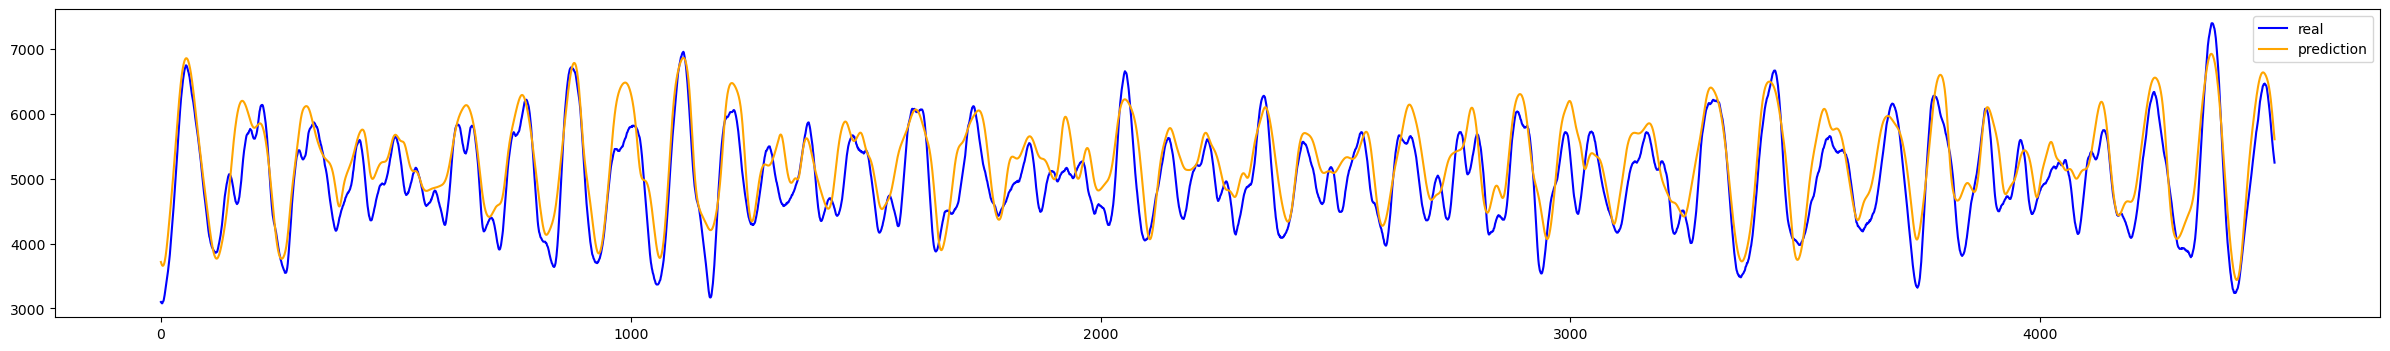

In [18]:
fan_force150_real3,fan_force150_pre3 = FanGuiHua_force1(valid50_y3_Force1,N_pre50_Y3_Force1)

np.savetxt('force1500_步长30_GRU.csv',np.hstack((fan_force150_real3,fan_force150_pre3)),delimiter=',')

In [19]:
# 输入50步长输出3步长Force2
force250_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[3480:,:], 4, 529)
force250_x3,force250_y3 = split_sequence(force250_scaled3, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [20]:
train_force250_x3, train_force250_y3, valid_force250_x3, valid_force250_y3 = split_train_valid(force250_x3,force250_y3, 4500, 7500, 12000)
train50_x3_Force2, valid50_x3_Force2 = np.hstack((pretrain_heave50_Y3, pretrain_surge50_Y3, pretrain_pitch50_Y3)), np.hstack((pre_heave50_Y3, pre_surge50_Y3, pre_pitch50_Y3))
train50_y3_Force2, valid50_y3_Force2 = train_force250_y3, valid_force250_y3

In [21]:
N_model50_3_Force2, N_history50_3_Force2, N_pre50_train_Y3_Force2, N_pre50_Y3_Force2 = Model_NN(train50_x3_Force2, train50_y3_Force2, valid50_x3_Force2, valid50_y3_Force2, lr=0.01, epochs=500, batch_size=256)

E:\Anaconda\envs\TensorFlow_env\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


Epoch 1/500
12/12 - 2s - loss: 0.3859 - val_loss: 0.1289 - 2s/epoch - 133ms/step
Epoch 2/500
12/12 - 0s - loss: 0.1432 - val_loss: 0.1398 - 136ms/epoch - 11ms/step
Epoch 3/500
12/12 - 0s - loss: 0.1222 - val_loss: 0.1274 - 129ms/epoch - 11ms/step
Epoch 4/500
12/12 - 0s - loss: 0.1196 - val_loss: 0.1283 - 130ms/epoch - 11ms/step
Epoch 5/500
12/12 - 0s - loss: 0.1172 - val_loss: 0.1247 - 139ms/epoch - 12ms/step
Epoch 6/500
12/12 - 0s - loss: 0.1143 - val_loss: 0.1225 - 144ms/epoch - 12ms/step
Epoch 7/500
12/12 - 0s - loss: 0.1120 - val_loss: 0.1198 - 124ms/epoch - 10ms/step
Epoch 8/500
12/12 - 0s - loss: 0.1091 - val_loss: 0.1161 - 126ms/epoch - 10ms/step
Epoch 9/500
12/12 - 0s - loss: 0.1063 - val_loss: 0.1155 - 124ms/epoch - 10ms/step
Epoch 10/500
12/12 - 0s - loss: 0.1037 - val_loss: 0.1101 - 124ms/epoch - 10ms/step
Epoch 11/500
12/12 - 0s - loss: 0.1035 - val_loss: 0.1083 - 143ms/epoch - 12ms/step
Epoch 12/500
12/12 - 0s - loss: 0.1026 - val_loss: 0.1076 - 124ms/epoch - 10ms/step
Epo

Epoch 99/500
12/12 - 0s - loss: 0.0825 - val_loss: 0.0908 - 126ms/epoch - 10ms/step
Epoch 100/500
12/12 - 0s - loss: 0.0743 - val_loss: 0.0906 - 129ms/epoch - 11ms/step
Epoch 101/500
12/12 - 0s - loss: 0.0757 - val_loss: 0.0945 - 124ms/epoch - 10ms/step
Epoch 102/500
12/12 - 0s - loss: 0.0803 - val_loss: 0.0901 - 115ms/epoch - 10ms/step
Epoch 103/500
12/12 - 0s - loss: 0.0822 - val_loss: 0.0903 - 117ms/epoch - 10ms/step
Epoch 104/500
12/12 - 0s - loss: 0.0743 - val_loss: 0.0905 - 122ms/epoch - 10ms/step
Epoch 105/500
12/12 - 0s - loss: 0.0749 - val_loss: 0.0934 - 120ms/epoch - 10ms/step
Epoch 106/500
12/12 - 0s - loss: 0.0793 - val_loss: 0.0889 - 132ms/epoch - 11ms/step
Epoch 107/500
12/12 - 0s - loss: 0.0818 - val_loss: 0.0906 - 117ms/epoch - 10ms/step
Epoch 108/500
12/12 - 0s - loss: 0.0747 - val_loss: 0.0903 - 119ms/epoch - 10ms/step
Epoch 109/500
12/12 - 0s - loss: 0.0742 - val_loss: 0.0915 - 117ms/epoch - 10ms/step
Epoch 110/500
12/12 - 0s - loss: 0.0783 - val_loss: 0.0882 - 129ms

Epoch 196/500
12/12 - 0s - loss: 0.0704 - val_loss: 0.0832 - 117ms/epoch - 10ms/step
Epoch 197/500
12/12 - 0s - loss: 0.0684 - val_loss: 0.0839 - 116ms/epoch - 10ms/step
Epoch 198/500
12/12 - 0s - loss: 0.0698 - val_loss: 0.0845 - 115ms/epoch - 10ms/step
Epoch 199/500
12/12 - 0s - loss: 0.0715 - val_loss: 0.0871 - 116ms/epoch - 10ms/step
Epoch 200/500
12/12 - 0s - loss: 0.0708 - val_loss: 0.0836 - 117ms/epoch - 10ms/step
Epoch 201/500
12/12 - 0s - loss: 0.0685 - val_loss: 0.0837 - 122ms/epoch - 10ms/step
Epoch 202/500
12/12 - 0s - loss: 0.0690 - val_loss: 0.0840 - 117ms/epoch - 10ms/step
Epoch 203/500
12/12 - 0s - loss: 0.0707 - val_loss: 0.0865 - 123ms/epoch - 10ms/step
Epoch 204/500
12/12 - 0s - loss: 0.0709 - val_loss: 0.0845 - 116ms/epoch - 10ms/step
Epoch 205/500
12/12 - 0s - loss: 0.0689 - val_loss: 0.0836 - 116ms/epoch - 10ms/step
Epoch 206/500
12/12 - 0s - loss: 0.0685 - val_loss: 0.0840 - 114ms/epoch - 9ms/step
Epoch 207/500
12/12 - 0s - loss: 0.0699 - val_loss: 0.0855 - 114ms

Epoch 293/500
12/12 - 0s - loss: 0.0650 - val_loss: 0.0809 - 116ms/epoch - 10ms/step
Epoch 294/500
12/12 - 0s - loss: 0.0650 - val_loss: 0.0809 - 120ms/epoch - 10ms/step
Epoch 295/500
12/12 - 0s - loss: 0.0649 - val_loss: 0.0809 - 130ms/epoch - 11ms/step
Epoch 296/500
12/12 - 0s - loss: 0.0649 - val_loss: 0.0808 - 117ms/epoch - 10ms/step
Epoch 297/500
12/12 - 0s - loss: 0.0649 - val_loss: 0.0808 - 124ms/epoch - 10ms/step
Epoch 298/500
12/12 - 0s - loss: 0.0648 - val_loss: 0.0807 - 116ms/epoch - 10ms/step
Epoch 299/500
12/12 - 0s - loss: 0.0648 - val_loss: 0.0807 - 116ms/epoch - 10ms/step
Epoch 300/500
12/12 - 0s - loss: 0.0648 - val_loss: 0.0806 - 117ms/epoch - 10ms/step
Epoch 301/500
12/12 - 0s - loss: 0.0647 - val_loss: 0.0806 - 115ms/epoch - 10ms/step
Epoch 302/500
12/12 - 0s - loss: 0.0647 - val_loss: 0.0806 - 117ms/epoch - 10ms/step
Epoch 303/500
12/12 - 0s - loss: 0.0646 - val_loss: 0.0805 - 118ms/epoch - 10ms/step
Epoch 304/500
12/12 - 0s - loss: 0.0646 - val_loss: 0.0805 - 125m

Epoch 390/500
12/12 - 0s - loss: 0.0585 - val_loss: 0.0740 - 126ms/epoch - 10ms/step
Epoch 391/500
12/12 - 0s - loss: 0.0564 - val_loss: 0.0838 - 135ms/epoch - 11ms/step
Epoch 392/500
12/12 - 0s - loss: 0.0585 - val_loss: 0.0738 - 118ms/epoch - 10ms/step
Epoch 393/500
12/12 - 0s - loss: 0.0563 - val_loss: 0.0842 - 119ms/epoch - 10ms/step
Epoch 394/500
12/12 - 0s - loss: 0.0584 - val_loss: 0.0737 - 140ms/epoch - 12ms/step
Epoch 395/500
12/12 - 0s - loss: 0.0562 - val_loss: 0.0843 - 115ms/epoch - 10ms/step
Epoch 396/500
12/12 - 0s - loss: 0.0582 - val_loss: 0.0738 - 115ms/epoch - 10ms/step
Epoch 397/500
12/12 - 0s - loss: 0.0561 - val_loss: 0.0840 - 118ms/epoch - 10ms/step
Epoch 398/500
12/12 - 0s - loss: 0.0579 - val_loss: 0.0740 - 115ms/epoch - 10ms/step
Epoch 399/500
12/12 - 0s - loss: 0.0561 - val_loss: 0.0832 - 124ms/epoch - 10ms/step
Epoch 400/500
12/12 - 0s - loss: 0.0576 - val_loss: 0.0745 - 121ms/epoch - 10ms/step
Epoch 401/500
12/12 - 0s - loss: 0.0561 - val_loss: 0.0820 - 115m

Epoch 487/500
12/12 - 0s - loss: 0.0515 - val_loss: 0.0840 - 122ms/epoch - 10ms/step
Epoch 488/500
12/12 - 0s - loss: 0.0512 - val_loss: 0.0916 - 117ms/epoch - 10ms/step
Epoch 489/500
12/12 - 0s - loss: 0.0520 - val_loss: 0.0935 - 116ms/epoch - 10ms/step
Epoch 490/500
12/12 - 0s - loss: 0.0526 - val_loss: 0.0883 - 117ms/epoch - 10ms/step
Epoch 491/500
12/12 - 0s - loss: 0.0521 - val_loss: 0.0902 - 116ms/epoch - 10ms/step
Epoch 492/500
12/12 - 0s - loss: 0.0523 - val_loss: 0.0950 - 118ms/epoch - 10ms/step
Epoch 493/500
12/12 - 0s - loss: 0.0532 - val_loss: 0.0882 - 115ms/epoch - 10ms/step
Epoch 494/500
12/12 - 0s - loss: 0.0524 - val_loss: 0.0841 - 116ms/epoch - 10ms/step
Epoch 495/500
12/12 - 0s - loss: 0.0512 - val_loss: 0.0939 - 124ms/epoch - 10ms/step
Epoch 496/500
12/12 - 0s - loss: 0.0524 - val_loss: 0.0924 - 134ms/epoch - 11ms/step
Epoch 497/500
12/12 - 0s - loss: 0.0528 - val_loss: 0.0868 - 117ms/epoch - 10ms/step
Epoch 498/500
12/12 - 0s - loss: 0.0533 - val_loss: 0.0923 - 116m

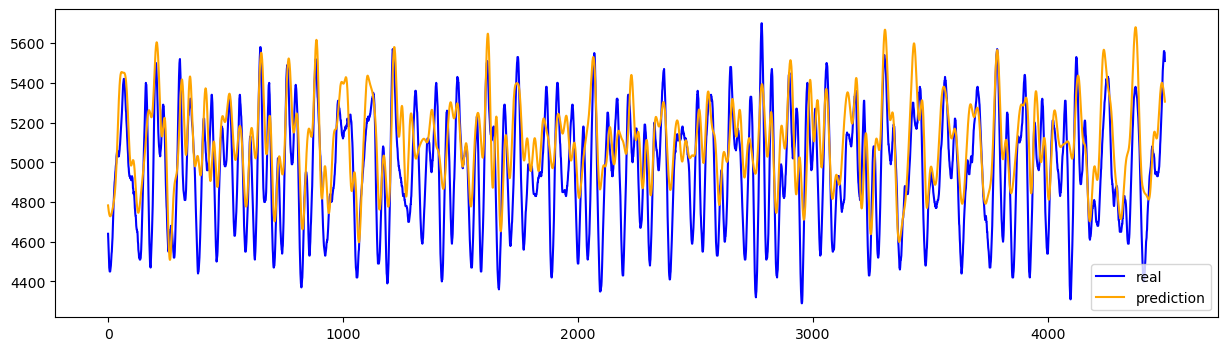

In [22]:
fan_force250_real3,fan_force250_pre3 = FanGuiHua_force2(valid50_y3_Force2,N_pre50_Y3_Force2)

np.savetxt('force2500_步长30_GRU.csv',np.hstack((fan_force250_real3,fan_force250_pre3)),delimiter=',')

In [23]:
RNSE(valid50_y3_Force1,N_pre50_Y3_Force1)
Acc(valid50_y3_Force1,N_pre50_Y3_Force1)

RMSE(sklearn): 0.14742096569790258
Acc: 0.9135661846462312


In [24]:
RNSE(valid50_y3_Force2,N_pre50_Y3_Force2)
Acc(valid50_y3_Force2,N_pre50_Y3_Force2)

RMSE(sklearn): 0.3171456719003933
Acc: 0.6880354219166934


#### 系泊缆力联合预测（时间窗500输出；步长40）

In [13]:
# 未来运动预测模型建立
train_heave50_x4, train_heave50_y4, valid_heave50_x4, valid_heave50_y4 = split_train_valid(heave50_x4,heave50_y4, 4500, 7500, 12000)
heave50_model4, heave50_history4, pre_heave50_Y4 = Model_GRU(train_heave50_x4, train_heave50_y4, valid_heave50_x4, valid_heave50_y4, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x4, train_surge50_y4, valid_surge50_x4, valid_surge50_y4 = split_train_valid(surge50_x4,surge50_y4, 4200, 7500, 12000)
surge50_model4, surge50_history4, pre_surge50_Y4 = Model_GRU(train_surge50_x4, train_surge50_y4, valid_surge50_x4, valid_surge50_y4, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x4, train_pitch50_y4, valid_pitch50_x4, valid_pitch50_y4 = split_train_valid(pitch50_x4,pitch50_y4, 4500, 7500, 12000)
pitch50_model4, pitch50_history4, pre_pitch50_Y4 = Model_GRU(train_pitch50_x4, train_pitch50_y4, valid_pitch50_x4, valid_pitch50_y4, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

E:\Anaconda\envs\TensorFlow_env\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


Epoch 1/30
60/60 - 13s - loss: 0.0898 - val_loss: 0.0846 - 13s/epoch - 218ms/step
Epoch 2/30
60/60 - 8s - loss: 0.0884 - val_loss: 0.0846 - 8s/epoch - 138ms/step
Epoch 3/30
60/60 - 8s - loss: 0.0884 - val_loss: 0.0846 - 8s/epoch - 138ms/step
Epoch 4/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 145ms/step
Epoch 5/30
60/60 - 8s - loss: 0.0884 - val_loss: 0.0846 - 8s/epoch - 138ms/step
Epoch 6/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 147ms/step
Epoch 7/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 145ms/step
Epoch 8/30
60/60 - 8s - loss: 0.0884 - val_loss: 0.0846 - 8s/epoch - 139ms/step
Epoch 9/30
60/60 - 8s - loss: 0.0884 - val_loss: 0.0846 - 8s/epoch - 140ms/step
Epoch 10/30
60/60 - 8s - loss: 0.0884 - val_loss: 0.0846 - 8s/epoch - 139ms/step
Epoch 11/30
60/60 - 8s - loss: 0.0884 - val_loss: 0.0846 - 8s/epoch - 141ms/step
Epoch 12/30
60/60 - 9s - loss: 0.0884 - val_loss: 0.0846 - 9s/epoch - 143ms/step
Epoch 13/30
60/60 - 8s - loss: 0.08

Epoch 21/30
60/60 - 8s - loss: 0.0723 - val_loss: 0.0701 - 8s/epoch - 140ms/step
Epoch 22/30
60/60 - 8s - loss: 0.0723 - val_loss: 0.0701 - 8s/epoch - 140ms/step
Epoch 23/30
60/60 - 8s - loss: 0.0723 - val_loss: 0.0701 - 8s/epoch - 139ms/step
Epoch 24/30
60/60 - 8s - loss: 0.0723 - val_loss: 0.0701 - 8s/epoch - 140ms/step
Epoch 25/30
60/60 - 9s - loss: 0.0723 - val_loss: 0.0701 - 9s/epoch - 145ms/step
Epoch 26/30
60/60 - 9s - loss: 0.0723 - val_loss: 0.0701 - 9s/epoch - 142ms/step
Epoch 27/30
60/60 - 9s - loss: 0.0723 - val_loss: 0.0701 - 9s/epoch - 145ms/step
Epoch 28/30
60/60 - 9s - loss: 0.0723 - val_loss: 0.0701 - 9s/epoch - 151ms/step
Epoch 29/30
60/60 - 8s - loss: 0.0723 - val_loss: 0.0701 - 8s/epoch - 140ms/step
Epoch 30/30
60/60 - 8s - loss: 0.0723 - val_loss: 0.0701 - 8s/epoch - 139ms/step
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_2 (GRU)                 (None, 

In [14]:
pretrain_heave50_Y4 = heave50_model4.predict(train_heave50_x4)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y4 = surge50_model4.predict(train_surge50_x4[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y4 = pitch50_model4.predict(train_pitch50_x4)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y4.shape)
print(pretrain_surge50_Y4.shape)
print(pretrain_pitch50_Y4.shape)

94/94 [==============================] - 3s 29ms/step
(3000, 500, 1)
(3000, 500, 1)
(3000, 500, 1)


In [15]:
# 输入50步长输出4步长Force1
force150_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[3470:,:], 4, 539)
force150_x4,force150_y4 = split_sequence(force150_scaled4, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [16]:
train_force150_x4, train_force150_y4, valid_force150_x4, valid_force150_y4 = split_train_valid(force150_x4,force150_y4, 4500, 7500, 12000)
train50_x4_Force1, valid50_x4_Force1 = np.hstack((pretrain_heave50_Y4, pretrain_surge50_Y4, pretrain_pitch50_Y4)), np.hstack((pre_heave50_Y4, pre_surge50_Y4, pre_pitch50_Y4))
train50_y4_Force1, valid50_y4_Force1 = train_force150_y4, valid_force150_y4

In [17]:
N_model50_4_Force1, N_history50_4_Force1, N_pre50_train_Y4_Force1, N_pre50_Y4_Force1 = Model_NN(train50_x4_Force1, train50_y4_Force1, valid50_x4_Force1, valid50_y4_Force1, lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000
12/12 - 2s - loss: 0.3018 - val_loss: 0.0713 - 2s/epoch - 173ms/step
Epoch 2/1000
12/12 - 0s - loss: 0.0951 - val_loss: 0.0628 - 160ms/epoch - 13ms/step
Epoch 3/1000
12/12 - 0s - loss: 0.0708 - val_loss: 0.0667 - 139ms/epoch - 12ms/step
Epoch 4/1000
12/12 - 0s - loss: 0.0663 - val_loss: 0.0602 - 140ms/epoch - 12ms/step
Epoch 5/1000
12/12 - 0s - loss: 0.0625 - val_loss: 0.0575 - 135ms/epoch - 11ms/step
Epoch 6/1000
12/12 - 0s - loss: 0.0587 - val_loss: 0.0530 - 130ms/epoch - 11ms/step
Epoch 7/1000
12/12 - 0s - loss: 0.0531 - val_loss: 0.0468 - 142ms/epoch - 12ms/step
Epoch 8/1000
12/12 - 0s - loss: 0.0461 - val_loss: 0.0405 - 131ms/epoch - 11ms/step
Epoch 9/1000
12/12 - 0s - loss: 0.0418 - val_loss: 0.0366 - 124ms/epoch - 10ms/step
Epoch 10/1000
12/12 - 0s - loss: 0.0389 - val_loss: 0.0360 - 133ms/epoch - 11ms/step
Epoch 11/1000
12/12 - 0s - loss: 0.0340 - val_loss: 0.0308 - 132ms/epoch - 11ms/step
Epoch 12/1000
12/12 - 0s - loss: 0.0320 - val_loss: 0.0292 - 124ms/epoch - 1

Epoch 98/1000
12/12 - 0s - loss: 0.0168 - val_loss: 0.0167 - 115ms/epoch - 10ms/step
Epoch 99/1000
12/12 - 0s - loss: 0.0167 - val_loss: 0.0166 - 115ms/epoch - 10ms/step
Epoch 100/1000
12/12 - 0s - loss: 0.0167 - val_loss: 0.0166 - 114ms/epoch - 9ms/step
Epoch 101/1000
12/12 - 0s - loss: 0.0167 - val_loss: 0.0166 - 114ms/epoch - 9ms/step
Epoch 102/1000
12/12 - 0s - loss: 0.0166 - val_loss: 0.0166 - 116ms/epoch - 10ms/step
Epoch 103/1000
12/12 - 0s - loss: 0.0166 - val_loss: 0.0166 - 121ms/epoch - 10ms/step
Epoch 104/1000
12/12 - 0s - loss: 0.0166 - val_loss: 0.0166 - 115ms/epoch - 10ms/step
Epoch 105/1000
12/12 - 0s - loss: 0.0166 - val_loss: 0.0166 - 117ms/epoch - 10ms/step
Epoch 106/1000
12/12 - 0s - loss: 0.0165 - val_loss: 0.0166 - 115ms/epoch - 10ms/step
Epoch 107/1000
12/12 - 0s - loss: 0.0165 - val_loss: 0.0166 - 115ms/epoch - 10ms/step
Epoch 108/1000
12/12 - 0s - loss: 0.0165 - val_loss: 0.0166 - 114ms/epoch - 9ms/step
Epoch 109/1000
12/12 - 0s - loss: 0.0165 - val_loss: 0.0166

Epoch 194/1000
12/12 - 0s - loss: 0.0152 - val_loss: 0.0164 - 129ms/epoch - 11ms/step
Epoch 195/1000
12/12 - 0s - loss: 0.0152 - val_loss: 0.0164 - 118ms/epoch - 10ms/step
Epoch 196/1000
12/12 - 0s - loss: 0.0152 - val_loss: 0.0164 - 130ms/epoch - 11ms/step
Epoch 197/1000
12/12 - 0s - loss: 0.0152 - val_loss: 0.0164 - 114ms/epoch - 9ms/step
Epoch 198/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0164 - 123ms/epoch - 10ms/step
Epoch 199/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0164 - 124ms/epoch - 10ms/step
Epoch 200/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0164 - 115ms/epoch - 10ms/step
Epoch 201/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0164 - 118ms/epoch - 10ms/step
Epoch 202/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0164 - 146ms/epoch - 12ms/step
Epoch 203/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0164 - 119ms/epoch - 10ms/step
Epoch 204/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.0164 - 123ms/epoch - 10ms/step
Epoch 205/1000
12/12 - 0s - loss: 0.0151 - val_loss: 0.

Epoch 290/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.0163 - 115ms/epoch - 10ms/step
Epoch 291/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.0162 - 110ms/epoch - 9ms/step
Epoch 292/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.0162 - 115ms/epoch - 10ms/step
Epoch 293/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.0162 - 115ms/epoch - 10ms/step
Epoch 294/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.0162 - 117ms/epoch - 10ms/step
Epoch 295/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.0162 - 120ms/epoch - 10ms/step
Epoch 296/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.0162 - 118ms/epoch - 10ms/step
Epoch 297/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.0162 - 120ms/epoch - 10ms/step
Epoch 298/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.0162 - 115ms/epoch - 10ms/step
Epoch 299/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.0162 - 115ms/epoch - 10ms/step
Epoch 300/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.0162 - 116ms/epoch - 10ms/step
Epoch 301/1000
12/12 - 0s - loss: 0.0144 - val_loss: 0.

Epoch 386/1000
12/12 - 0s - loss: 0.0130 - val_loss: 0.0129 - 116ms/epoch - 10ms/step
Epoch 387/1000
12/12 - 0s - loss: 0.0130 - val_loss: 0.0128 - 116ms/epoch - 10ms/step
Epoch 388/1000
12/12 - 0s - loss: 0.0130 - val_loss: 0.0134 - 123ms/epoch - 10ms/step
Epoch 389/1000
12/12 - 0s - loss: 0.0129 - val_loss: 0.0130 - 114ms/epoch - 9ms/step
Epoch 390/1000
12/12 - 0s - loss: 0.0131 - val_loss: 0.0129 - 128ms/epoch - 11ms/step
Epoch 391/1000
12/12 - 0s - loss: 0.0134 - val_loss: 0.0130 - 117ms/epoch - 10ms/step
Epoch 392/1000
12/12 - 0s - loss: 0.0136 - val_loss: 0.0135 - 116ms/epoch - 10ms/step
Epoch 393/1000
12/12 - 0s - loss: 0.0134 - val_loss: 0.0132 - 114ms/epoch - 9ms/step
Epoch 394/1000
12/12 - 0s - loss: 0.0130 - val_loss: 0.0130 - 115ms/epoch - 10ms/step
Epoch 395/1000
12/12 - 0s - loss: 0.0126 - val_loss: 0.0129 - 115ms/epoch - 10ms/step
Epoch 396/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0128 - 123ms/epoch - 10ms/step
Epoch 397/1000
12/12 - 0s - loss: 0.0126 - val_loss: 0.0

...

Epoch 578/1000
12/12 - 0s - loss: 0.0110 - val_loss: 0.0130 - 151ms/epoch - 13ms/step
Epoch 579/1000
12/12 - 0s - loss: 0.0113 - val_loss: 0.0131 - 147ms/epoch - 12ms/step
Epoch 580/1000
12/12 - 0s - loss: 0.0115 - val_loss: 0.0140 - 122ms/epoch - 10ms/step
Epoch 581/1000
12/12 - 0s - loss: 0.0125 - val_loss: 0.0228 - 136ms/epoch - 11ms/step
Epoch 582/1000
12/12 - 0s - loss: 0.0168 - val_loss: 0.0135 - 127ms/epoch - 11ms/step
Epoch 583/1000
12/12 - 0s - loss: 0.0143 - val_loss: 0.0137 - 147ms/epoch - 12ms/step
Epoch 584/1000
12/12 - 0s - loss: 0.0116 - val_loss: 0.0137 - 131ms/epoch - 11ms/step
Epoch 585/1000
12/12 - 0s - loss: 0.0118 - val_loss: 0.0140 - 146ms/epoch - 12ms/step
Epoch 586/1000
12/12 - 0s - loss: 0.0129 - val_loss: 0.0205 - 143ms/epoch - 12ms/step
Epoch 587/1000
12/12 - 0s - loss: 0.0165 - val_loss: 0.0145 - 128ms/epoch - 11ms/step
Epoch 588/1000
12/12 - 0s - loss: 0.0130 - val_loss: 0.0134 - 132ms/epoch - 11ms/step
Epoch 589/1000
12/12 - 0s - loss: 0.0112 - val_loss: 0

Epoch 674/1000
12/12 - 0s - loss: 0.0121 - val_loss: 0.0193 - 115ms/epoch - 10ms/step
Epoch 675/1000
12/12 - 0s - loss: 0.0143 - val_loss: 0.0142 - 116ms/epoch - 10ms/step
Epoch 676/1000
12/12 - 0s - loss: 0.0118 - val_loss: 0.0159 - 116ms/epoch - 10ms/step
Epoch 677/1000
12/12 - 0s - loss: 0.0113 - val_loss: 0.0145 - 115ms/epoch - 10ms/step
Epoch 678/1000
12/12 - 0s - loss: 0.0119 - val_loss: 0.0168 - 118ms/epoch - 10ms/step
Epoch 679/1000
12/12 - 0s - loss: 0.0122 - val_loss: 0.0186 - 115ms/epoch - 10ms/step
Epoch 680/1000
12/12 - 0s - loss: 0.0140 - val_loss: 0.0145 - 133ms/epoch - 11ms/step
Epoch 681/1000
12/12 - 0s - loss: 0.0111 - val_loss: 0.0149 - 116ms/epoch - 10ms/step
Epoch 682/1000
12/12 - 0s - loss: 0.0113 - val_loss: 0.0190 - 116ms/epoch - 10ms/step
Epoch 683/1000
12/12 - 0s - loss: 0.0132 - val_loss: 0.0143 - 115ms/epoch - 10ms/step
Epoch 684/1000
12/12 - 0s - loss: 0.0112 - val_loss: 0.0139 - 116ms/epoch - 10ms/step
Epoch 685/1000
12/12 - 0s - loss: 0.0107 - val_loss: 0

Epoch 770/1000
12/12 - 0s - loss: 0.0197 - val_loss: 0.0378 - 115ms/epoch - 10ms/step
Epoch 771/1000
12/12 - 0s - loss: 0.0218 - val_loss: 0.0358 - 115ms/epoch - 10ms/step
Epoch 772/1000
12/12 - 0s - loss: 0.0243 - val_loss: 0.0327 - 115ms/epoch - 10ms/step
Epoch 773/1000
12/12 - 0s - loss: 0.0199 - val_loss: 0.0187 - 114ms/epoch - 9ms/step
Epoch 774/1000
12/12 - 0s - loss: 0.0181 - val_loss: 0.0146 - 115ms/epoch - 10ms/step
Epoch 775/1000
12/12 - 0s - loss: 0.0174 - val_loss: 0.0161 - 117ms/epoch - 10ms/step
Epoch 776/1000
12/12 - 0s - loss: 0.0133 - val_loss: 0.0156 - 117ms/epoch - 10ms/step
Epoch 777/1000
12/12 - 0s - loss: 0.0120 - val_loss: 0.0211 - 123ms/epoch - 10ms/step
Epoch 778/1000
12/12 - 0s - loss: 0.0176 - val_loss: 0.0157 - 116ms/epoch - 10ms/step
Epoch 779/1000
12/12 - 0s - loss: 0.0160 - val_loss: 0.0151 - 115ms/epoch - 10ms/step
Epoch 780/1000
12/12 - 0s - loss: 0.0110 - val_loss: 0.0155 - 115ms/epoch - 10ms/step
Epoch 781/1000
12/12 - 0s - loss: 0.0120 - val_loss: 0.

Epoch 866/1000
12/12 - 0s - loss: 0.0111 - val_loss: 0.0217 - 131ms/epoch - 11ms/step
Epoch 867/1000
12/12 - 0s - loss: 0.0111 - val_loss: 0.0291 - 116ms/epoch - 10ms/step
Epoch 868/1000
12/12 - 0s - loss: 0.0162 - val_loss: 0.0333 - 117ms/epoch - 10ms/step
Epoch 869/1000
12/12 - 0s - loss: 0.0221 - val_loss: 0.0228 - 117ms/epoch - 10ms/step
Epoch 870/1000
12/12 - 0s - loss: 0.0202 - val_loss: 0.0186 - 116ms/epoch - 10ms/step
Epoch 871/1000
12/12 - 0s - loss: 0.0193 - val_loss: 0.0150 - 115ms/epoch - 10ms/step
Epoch 872/1000
12/12 - 0s - loss: 0.0139 - val_loss: 0.0169 - 116ms/epoch - 10ms/step
Epoch 873/1000
12/12 - 0s - loss: 0.0121 - val_loss: 0.0194 - 121ms/epoch - 10ms/step
Epoch 874/1000
12/12 - 0s - loss: 0.0136 - val_loss: 0.0173 - 122ms/epoch - 10ms/step
Epoch 875/1000
12/12 - 0s - loss: 0.0118 - val_loss: 0.0157 - 119ms/epoch - 10ms/step
Epoch 876/1000
12/12 - 0s - loss: 0.0094 - val_loss: 0.0164 - 117ms/epoch - 10ms/step
Epoch 877/1000
12/12 - 0s - loss: 0.0082 - val_loss: 0

Epoch 962/1000
12/12 - 0s - loss: 0.0053 - val_loss: 0.0178 - 139ms/epoch - 12ms/step
Epoch 963/1000
12/12 - 0s - loss: 0.0059 - val_loss: 0.0186 - 139ms/epoch - 12ms/step
Epoch 964/1000
12/12 - 0s - loss: 0.0063 - val_loss: 0.0184 - 149ms/epoch - 12ms/step
Epoch 965/1000
12/12 - 0s - loss: 0.0068 - val_loss: 0.0182 - 125ms/epoch - 10ms/step
Epoch 966/1000
12/12 - 0s - loss: 0.0083 - val_loss: 0.0185 - 134ms/epoch - 11ms/step
Epoch 967/1000
12/12 - 0s - loss: 0.0090 - val_loss: 0.0194 - 117ms/epoch - 10ms/step
Epoch 968/1000
12/12 - 0s - loss: 0.0068 - val_loss: 0.0213 - 116ms/epoch - 10ms/step
Epoch 969/1000
12/12 - 0s - loss: 0.0109 - val_loss: 0.0219 - 135ms/epoch - 11ms/step
Epoch 970/1000
12/12 - 0s - loss: 0.0088 - val_loss: 0.0204 - 130ms/epoch - 11ms/step
Epoch 971/1000
12/12 - 0s - loss: 0.0090 - val_loss: 0.0198 - 115ms/epoch - 10ms/step
Epoch 972/1000
12/12 - 0s - loss: 0.0077 - val_loss: 0.0178 - 115ms/epoch - 10ms/step
Epoch 973/1000
12/12 - 0s - loss: 0.0068 - val_loss: 0

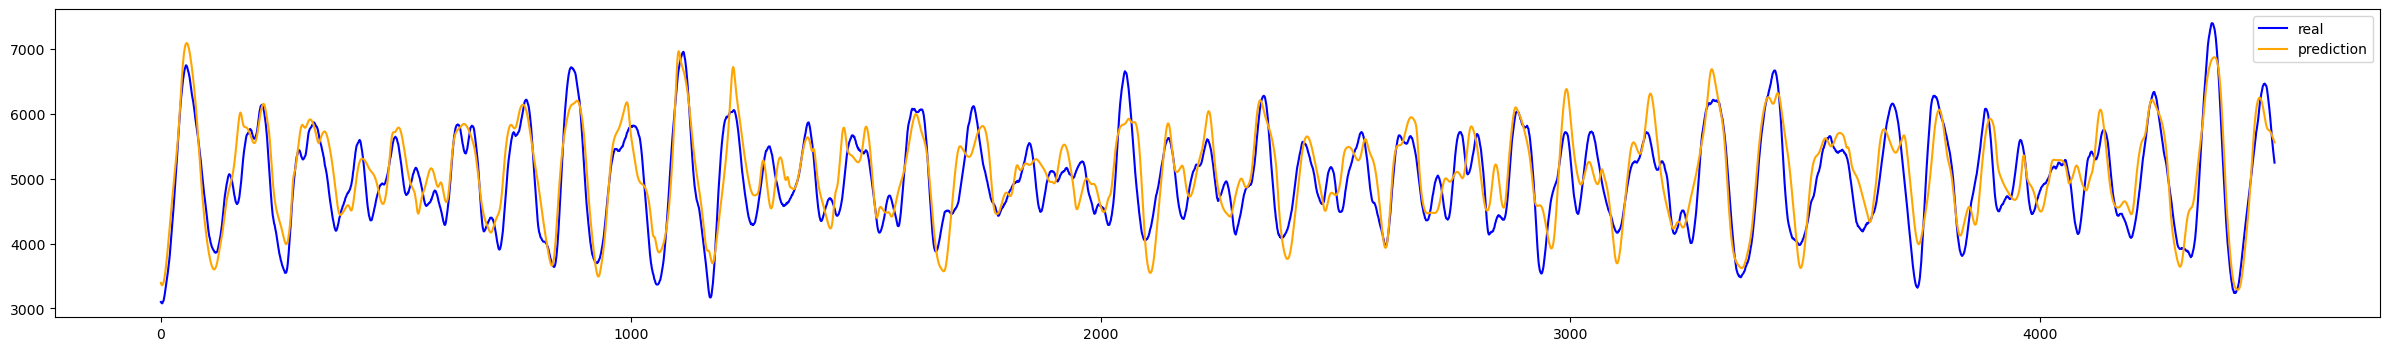

In [18]:
fan_force150_real4,fan_force150_pre4 = FanGuiHua_force1(valid50_y4_Force1,N_pre50_Y4_Force1)

np.savetxt('force1500_步长40_GRU.csv',np.hstack((fan_force150_real4,fan_force150_pre4)),delimiter=',')

In [19]:
# 输入50步长输出4步长Force2
force250_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[3470:,:], 4, 539)
force250_x4,force250_y4 = split_sequence(force250_scaled4, 500)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [20]:
train_force250_x4, train_force250_y4, valid_force250_x4, valid_force250_y4 = split_train_valid(force250_x4,force250_y4, 4500, 7500, 12000)
train50_x4_Force2, valid50_x4_Force2 = np.hstack((pretrain_heave50_Y4, pretrain_surge50_Y4, pretrain_pitch50_Y4)), np.hstack((pre_heave50_Y4, pre_surge50_Y4, pre_pitch50_Y4))
train50_y4_Force2, valid50_y4_Force2 = train_force250_y4, valid_force250_y4

In [21]:
N_model50_4_Force2, N_history50_4_Force2, N_pre50_train_Y4_Force2, N_pre50_Y4_Force2 = Model_NN(train50_x4_Force2, train50_y4_Force2, valid50_x4_Force2, valid50_y4_Force2, lr=0.01, epochs=400, batch_size=256)

E:\Anaconda\envs\TensorFlow_env\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


Epoch 1/400
12/12 - 2s - loss: 0.3335 - val_loss: 0.1483 - 2s/epoch - 149ms/step
Epoch 2/400
12/12 - 0s - loss: 0.1443 - val_loss: 0.1274 - 144ms/epoch - 12ms/step
Epoch 3/400
12/12 - 0s - loss: 0.1207 - val_loss: 0.1286 - 132ms/epoch - 11ms/step
Epoch 4/400
12/12 - 0s - loss: 0.1173 - val_loss: 0.1253 - 133ms/epoch - 11ms/step
Epoch 5/400
12/12 - 0s - loss: 0.1157 - val_loss: 0.1243 - 123ms/epoch - 10ms/step
Epoch 6/400
12/12 - 0s - loss: 0.1135 - val_loss: 0.1216 - 126ms/epoch - 10ms/step
Epoch 7/400
12/12 - 0s - loss: 0.1108 - val_loss: 0.1173 - 122ms/epoch - 10ms/step
Epoch 8/400
12/12 - 0s - loss: 0.1078 - val_loss: 0.1182 - 122ms/epoch - 10ms/step
Epoch 9/400
12/12 - 0s - loss: 0.1062 - val_loss: 0.1118 - 123ms/epoch - 10ms/step
Epoch 10/400
12/12 - 0s - loss: 0.1027 - val_loss: 0.1101 - 122ms/epoch - 10ms/step
Epoch 11/400
12/12 - 0s - loss: 0.1038 - val_loss: 0.1081 - 131ms/epoch - 11ms/step
Epoch 12/400
12/12 - 0s - loss: 0.1056 - val_loss: 0.1099 - 128ms/epoch - 11ms/step
Epo

Epoch 99/400
12/12 - 0s - loss: 0.0892 - val_loss: 0.0953 - 127ms/epoch - 11ms/step
Epoch 100/400
12/12 - 0s - loss: 0.0820 - val_loss: 0.0949 - 120ms/epoch - 10ms/step
Epoch 101/400
12/12 - 0s - loss: 0.0864 - val_loss: 0.0928 - 118ms/epoch - 10ms/step
Epoch 102/400
12/12 - 0s - loss: 0.0890 - val_loss: 0.0952 - 120ms/epoch - 10ms/step
Epoch 103/400
12/12 - 0s - loss: 0.0817 - val_loss: 0.0949 - 125ms/epoch - 10ms/step
Epoch 104/400
12/12 - 0s - loss: 0.0861 - val_loss: 0.0927 - 122ms/epoch - 10ms/step
Epoch 105/400
12/12 - 0s - loss: 0.0888 - val_loss: 0.0951 - 116ms/epoch - 10ms/step
Epoch 106/400
12/12 - 0s - loss: 0.0815 - val_loss: 0.0949 - 120ms/epoch - 10ms/step
Epoch 107/400
12/12 - 0s - loss: 0.0858 - val_loss: 0.0926 - 117ms/epoch - 10ms/step
Epoch 108/400
12/12 - 0s - loss: 0.0886 - val_loss: 0.0950 - 122ms/epoch - 10ms/step
Epoch 109/400
12/12 - 0s - loss: 0.0812 - val_loss: 0.0949 - 116ms/epoch - 10ms/step
Epoch 110/400
12/12 - 0s - loss: 0.0855 - val_loss: 0.0926 - 118ms

Epoch 196/400
12/12 - 0s - loss: 0.0753 - val_loss: 0.0961 - 117ms/epoch - 10ms/step
Epoch 197/400
12/12 - 0s - loss: 0.0813 - val_loss: 0.0915 - 115ms/epoch - 10ms/step
Epoch 198/400
12/12 - 0s - loss: 0.0848 - val_loss: 0.0915 - 117ms/epoch - 10ms/step
Epoch 199/400
12/12 - 0s - loss: 0.0778 - val_loss: 0.0879 - 117ms/epoch - 10ms/step
Epoch 200/400
12/12 - 0s - loss: 0.0752 - val_loss: 0.0994 - 119ms/epoch - 10ms/step
Epoch 201/400
12/12 - 0s - loss: 0.0832 - val_loss: 0.0901 - 118ms/epoch - 10ms/step
Epoch 202/400
12/12 - 0s - loss: 0.0807 - val_loss: 0.0912 - 122ms/epoch - 10ms/step
Epoch 203/400
12/12 - 0s - loss: 0.0756 - val_loss: 0.0958 - 124ms/epoch - 10ms/step
Epoch 204/400
12/12 - 0s - loss: 0.0825 - val_loss: 0.0881 - 117ms/epoch - 10ms/step
Epoch 205/400
12/12 - 0s - loss: 0.0826 - val_loss: 0.0897 - 124ms/epoch - 10ms/step
Epoch 206/400
12/12 - 0s - loss: 0.0745 - val_loss: 0.0956 - 122ms/epoch - 10ms/step
Epoch 207/400
12/12 - 0s - loss: 0.0782 - val_loss: 0.1016 - 112m

Epoch 293/400
12/12 - 0s - loss: 0.0731 - val_loss: 0.0930 - 116ms/epoch - 10ms/step
Epoch 294/400
12/12 - 0s - loss: 0.0799 - val_loss: 0.0897 - 117ms/epoch - 10ms/step
Epoch 295/400
12/12 - 0s - loss: 0.0754 - val_loss: 0.0880 - 118ms/epoch - 10ms/step
Epoch 296/400
12/12 - 0s - loss: 0.0720 - val_loss: 0.0886 - 115ms/epoch - 10ms/step
Epoch 297/400
12/12 - 0s - loss: 0.0781 - val_loss: 0.0848 - 116ms/epoch - 10ms/step
Epoch 298/400
12/12 - 0s - loss: 0.0780 - val_loss: 0.0860 - 117ms/epoch - 10ms/step
Epoch 299/400
12/12 - 0s - loss: 0.0709 - val_loss: 0.0900 - 118ms/epoch - 10ms/step
Epoch 300/400
12/12 - 0s - loss: 0.0751 - val_loss: 0.0929 - 118ms/epoch - 10ms/step
Epoch 301/400
12/12 - 0s - loss: 0.0806 - val_loss: 0.0910 - 116ms/epoch - 10ms/step
Epoch 302/400
12/12 - 0s - loss: 0.0733 - val_loss: 0.0881 - 117ms/epoch - 10ms/step
Epoch 303/400
12/12 - 0s - loss: 0.0726 - val_loss: 0.0908 - 120ms/epoch - 10ms/step
Epoch 304/400
12/12 - 0s - loss: 0.0792 - val_loss: 0.0865 - 116m

Epoch 390/400
12/12 - 0s - loss: 0.0678 - val_loss: 0.0892 - 139ms/epoch - 12ms/step
Epoch 391/400
12/12 - 0s - loss: 0.0744 - val_loss: 0.0847 - 118ms/epoch - 10ms/step
Epoch 392/400
12/12 - 0s - loss: 0.0716 - val_loss: 0.0865 - 117ms/epoch - 10ms/step
Epoch 393/400
12/12 - 0s - loss: 0.0769 - val_loss: 0.0850 - 116ms/epoch - 10ms/step
Epoch 394/400
12/12 - 0s - loss: 0.0715 - val_loss: 0.0934 - 134ms/epoch - 11ms/step
Epoch 395/400
12/12 - 0s - loss: 0.0800 - val_loss: 0.0869 - 120ms/epoch - 10ms/step
Epoch 396/400
12/12 - 0s - loss: 0.0727 - val_loss: 0.0839 - 123ms/epoch - 10ms/step
Epoch 397/400
12/12 - 0s - loss: 0.0721 - val_loss: 0.0826 - 117ms/epoch - 10ms/step
Epoch 398/400
12/12 - 0s - loss: 0.0671 - val_loss: 0.0840 - 119ms/epoch - 10ms/step
Epoch 399/400
12/12 - 0s - loss: 0.0721 - val_loss: 0.0828 - 117ms/epoch - 10ms/step
Epoch 400/400
12/12 - 0s - loss: 0.0721 - val_loss: 0.0845 - 114ms/epoch - 9ms/step
Model: "sequential_4"
____________________________________________

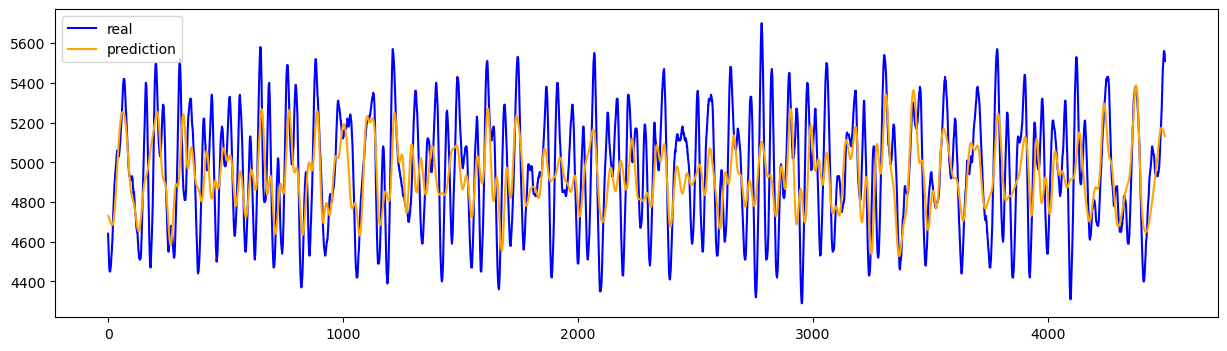

In [22]:
fan_force250_real4,fan_force250_pre4 = FanGuiHua_force2(valid50_y4_Force2,N_pre50_Y4_Force2)

np.savetxt('force2500_步长40_GRU.csv',np.hstack((fan_force250_real4,fan_force250_pre4)),delimiter=',')

In [23]:
RNSE(valid50_y4_Force1,N_pre50_Y4_Force1)
Acc(valid50_y4_Force1,N_pre50_Y4_Force1)

RMSE(sklearn): 0.13437493443426532
Acc: 0.9382865959139225


In [24]:
RNSE(valid50_y4_Force2,N_pre50_Y4_Force2)
Acc(valid50_y4_Force2,N_pre50_Y4_Force2)

RMSE(sklearn): 0.29065907893440496
Acc: 0.5181154083565517
